# FR_extra — the full-retrieval (FR) results section, isolated

This notebook is the **capstone retrieval-results section (§16)** split out of
`riccati_solver_VOCALS_retrieval.ipynb` so it can be re-run against the canonical bundles
without executing the main notebook. It consumes:

* **`../../canon_ve046tik_FR_14July26/_ve046_tik_fr_parts/`** (or `runs/_ve046_tik_fr_parts/` on
  the cluster) — the **canonical ve046tik config-A sidecars** (125 profiles, consolidated
  2026-07-14; see `hpc/FINAL_RESULTS_MANIFEST.md`, "ve046 campaign"), with the **idx-32 pathology
  promotion** (2026-07-19, `_ve046_tik_fr_parts_pathology_candidates/32_fq_pathology_thr01/`)
  overlaid as a merged view. *Unless otherwise stated, no other FR results are to be used* (the
  `92_notik_FR` candidate is λ=0 — non-canonical §17 hyperparameter evidence).
* **`../../ve046_adia_bundle_1137436/_ve046_tik_adia_parts/`** (or `runs/_ve046_tik_adia_parts/`)
  — the **matched adiabatic-retrieval campaign** (k=1, landed 2026-07-17), with the idx-8/92/119
  pathology promotions (`_ve046_adia_pathology_parts/`) overlaid: the same 125 profiles
  re-retrieved with the state forced to the 3-parameter adiabat class. This is the model-class
  ablation **competitor** used throughout.
* `scripts/retrieval_analysis.py` — the post-hoc metric suite (τ-normalized W1 + LWP);
* `scripts/plot_retrieved_profile.py` — the **default format** for plotting retrieved profiles
  (all single-profile figures below go through it, never inline one-offs; here with its
  `PLOT_K1_PARTS` overlay showing the k=1 competitor on every panel).

The profile plots build the campaign forward once (the ve046/re22 fixed-quadrature optics table
is generated into `../data/` on first use, ~minutes); population figures need only the sidecars.
Without the bundles, population cells fall back to `docs/cached_results/retrieval_summary_ve046.json`
and `retrieval_summary_ve046_adia.json`.

In [1]:
# Preamble — paths + the ve046 campaign environment. Run FIRST: the OSSE_* env vars must be
# exported BEFORE any pydisort_riccati_jax import (osse_config reads them at import time and
# signature-rekeys every cache — a wrong/missing export is refused, never silently mixed).
import os, sys, glob, json, subprocess
from pathlib import Path
import importlib.util as _ilu
import numpy as np
import matplotlib.pyplot as plt

def _find_repo(start=None):
    p = Path(start or Path.cwd()).resolve()
    for q in [p, *p.parents]:
        if (q / 'scripts' / 'retrieval_analysis.py').exists():
            return q
    raise FileNotFoundError('repo root (scripts/retrieval_analysis.py) not found')

REPO = _find_repo()
WORKSPACE = REPO.parent
_cr = REPO / 'docs' / 'cached_results'

# the ve046 observing system (mirrors scripts/plot_retrieved_profile.py defaults)
for _k, _v in {'OSSE_VEFF': '0.046', 'OSSE_RE_MAX': '22', 'OSSE_QUADRATURE': 'fixed',
               'OSSE_RE_GRID_N': '181', 'OSSE_N_RADII': '4096',
               'OPTICS_CACHE': str(WORKSPACE / 'data' / 'optics_table_10band_nleg1536_re22_fq.npz'),
               'RADIANCE_CACHE': str(WORKSPACE / 'data' / 'osse_radiances_ve046_fq.npz'),
               'JAX_PLATFORMS': 'cpu', 'PYDISORT_RICCATI_JAX_X64': '1'}.items():
    os.environ.setdefault(_k, _v)

# the canonical FR sidecars + the k=1 adiabatic-retrieval competitor sidecars.
# BOTH canonical sets are the campaign records with the user-ratified pathology-treatment
# promotions (true-τ_bot-fed prior mean; the provenance flag travels with any number quoting
# them): FR promotes idx 32 (2026-07-19, from _ve046_tik_fr_parts_pathology_candidates/
# 32_fq_pathology_thr01 — the 92_notik_FR candidate is NOT canonical: λ=0 breaks the
# all-else-equal rule, held as §17 hyperparameter evidence); k=1 promotes idx 8, 92 and 119
# (idx 92 ratified 2026-07-19: its treated χ²ᵣ lands inside the campaign tail, so the same
# truth-blind rescue rule applies even though the de-inverted profile agrees less well with
# the inverted truth). Built as DETERMINISTIC untracked merged views (base overwritten first,
# then the promotions) so neither source bundle is mutated.
import shutil
_fr_base = next((d for d in [WORKSPACE / 'canon_ve046tik_FR_14July26' / '_ve046_tik_fr_parts',
                             REPO / 'runs' / '_ve046_tik_fr_parts'] if d.is_dir()), None)
_fr_promo = (WORKSPACE / 'canon_ve046tik_FR_14July26' /
             '_ve046_tik_fr_parts_pathology_candidates' / '32_fq_pathology_thr01')
_k1_base = next((d for d in [WORKSPACE / 've046_adia_bundle_1137436' / '_ve046_tik_adia_parts',
                             REPO / 'runs' / '_ve046_tik_adia_parts'] if d.is_dir()), None)
_k1_path = next((d for d in [WORKSPACE / 've046_adia_bundle_1137436' / '_ve046_adia_pathology_parts',
                             REPO / 'runs' / '_ve046_adia_pathology_parts'] if d.is_dir()), None)

def _merge(base, promo, dst, flag, flags):
    if base is None:
        return None
    if promo is None or not promo.is_dir():
        return base
    dst.mkdir(parents=True, exist_ok=True)
    for _f in base.iterdir():
        if _f.is_file():
            shutil.copy2(_f, dst / _f.name)
    for _f in promo.iterdir():
        shutil.copy2(_f, dst / _f.name)                  # promoted records override
        if _f.name.endswith('_A.npz'):
            flags[int(_f.name.split('_')[0])] = flag
    return dst

FR_PROV_FLAG, K1_PROV_FLAG = {}, {}
CANON_DIR = _merge(_fr_base, _fr_promo, REPO / 'runs' / '_ve046_tik_fr_merged',
                   'FR pathology promotion (true-τ_bot-fed prior +3rd-decimal dither, thr 0.1, fq)',
                   FR_PROV_FLAG)
K1_DIR = _merge(_k1_base, _k1_path, REPO / 'runs' / '_ve046_tik_adia_merged',
                'k=1 pathology promotion (true-τ_bot-fed prior)', K1_PROV_FLAG)

_spec = _ilu.spec_from_file_location('ra', REPO / 'scripts' / 'retrieval_analysis.py')
ra = _ilu.module_from_spec(_spec); sys.modules['ra'] = ra; _spec.loader.exec_module(ra)

# The DEFAULT single-profile plot format (docs/figures/bad_Adiabest-fit.png template) —
# every retrieved-profile figure is rendered by this script, never by inline plotting.
PLOT_SCRIPT = REPO / 'scripts' / 'plot_retrieved_profile.py'
FIG_DIR = REPO / 'runs' / 'fig_fr_extra'
FIG_DIR.mkdir(parents=True, exist_ok=True)

def plot_profile(idx):
    """Render profile ``idx`` (config A, canonical parts dir) via the standard script;
    returns the PNG path. Cached on disk — delete runs/fig_fr_extra/ to force re-render."""
    out = FIG_DIR / f've046_idx{idx}_profile.png'
    if not out.exists():
        _env = dict(os.environ)
        if K1_DIR is not None:                        # overlay the k=1 competitor (purple dotted)
            _env['PLOT_K1_PARTS'] = str(K1_DIR)
        subprocess.run([sys.executable, str(PLOT_SCRIPT), str(idx), 'A', str(CANON_DIR), str(out)],
                       check=True, cwd=REPO, capture_output=True, text=True, env=_env)
    return out

def profile_montage(idx_tags, ncol=3):
    """Display standard-format profile PNGs side by side (tag printed above each)."""
    n = len(idx_tags); nrow = -(-n // ncol)
    fig, ax = plt.subplots(nrow, ncol, figsize=(5.5 * ncol, 6.6 * nrow), squeeze=False)
    for a in ax.ravel():
        a.set_axis_off()
    for a, (idx, tag) in zip(ax.ravel(), idx_tags):
        a.imshow(plt.imread(plot_profile(idx)))
        a.set_title(tag, fontsize=10, fontweight='bold')
    fig.tight_layout(); plt.show()

print(f'repo: {REPO}\ncanonical FR sidecars: {CANON_DIR if CANON_DIR else "NOT FOUND (cache fallback)"}'
      f'\nk=1 competitor sidecars: {K1_DIR if K1_DIR else "NOT FOUND (cache fallback)"}'
      f'\nFR promoted records: {sorted(FR_PROV_FLAG) if FR_PROV_FLAG else "none (candidates dir absent)"}'
      f'\nk=1 promoted records: {sorted(K1_PROV_FLAG) if K1_PROV_FLAG else "none (pathology dir absent)"}')

repo: /home/jovyan/cloud_profile_retrieval/Pythonic-DISORT_inhomogeneous_atmosphere
canonical FR sidecars: /home/jovyan/cloud_profile_retrieval/Pythonic-DISORT_inhomogeneous_atmosphere/runs/_ve046_tik_fr_merged
k=1 competitor sidecars: /home/jovyan/cloud_profile_retrieval/Pythonic-DISORT_inhomogeneous_atmosphere/runs/_ve046_tik_adia_merged
FR promoted records: [32]
k=1 promoted records: [8, 92, 119]


## 16. The capstone: all-125 full retrievals — does the free-node $r_e(\tau)$ beat an adiabatic retrieval on the same information?

Every valid VOCALS-REx profile (125 of 126; the τ≈1585 outlier is excluded) is inverted by the joint log-space Gauss–Newton OE of §11–§14 — state $x=[r_e(s_{\rm nodes}),\,r_{\rm base},\,\tau_{\rm bot}]$, the 10-band × 24-view observing system (NQuad=48, $\mu_0$=0.9), noiseless OSSE observation, OCI-2 % assumed $S_\epsilon$, float64, `tol=1e-4` — in the **ve046tik campaign configuration**:

* **self-consistent corrected-width optics**: $v_e=0.046$ (the §5c min-RMS constant), $r_e\!\le\!22$ µm fixed-quadrature (`fq`) table — truth radiances and retrieval forward share one table, closing the "your DSD width is wrong" loop that the published $v_e=0.10$ campaign left open;
* **curvature (2nd-difference) Tikhonov, λ=1.0** (§11d; energy-weighted, grid-spacing-independent) — suppresses the data/prior-seam kink the C⁰ OU prior cannot;
* **one prior configuration**: prior mean = first guess = the **leave-one-flight-out climatology** adiabatic anchor (leak-free, operationally honest). The old config B (prior-*draw* robustness) was settled by the batch-3 campaign and is retired here; the full batch-3 (v_e=0.10, 250+1, A/B) section this replaces is preserved in git history.

**The canonical set** is `canon_ve046tik_FR_14July26` — the consolidated 125/125 config-A records of 2026-07-14 (`hpc/FINAL_RESULTS_MANIFEST.md`, "ve046 campaign"): **idx 32, 49, 54, 57 are the promoted pathology records** (`max_n_outer=3`, re-mesh threshold 0.1, and a **true-τ_bot-fed prior mean** — τ_bot itself still retrieved — a provenance flag that travels with any number quoting them; idx 49/57 ended on tier-3 k=2 quasi-adiabat grids; idx 32's promotion landed 2026-07-19 on the fq radiance pathway — the superseded record's $\chi^2_r$ 0.076 / $\hat{W}_1$ 4.10 became 0.0043 / 1.65 on a leaner 4-node grid, and the *decisive* lever was a 3rd-decimal **dither** of the τ_bot prior anchor, i.e. a pure seed change — the un-dithered true-τ_bot feed had already been tried and did not help: idx 32 was a Gauss–Newton **basin** on the FR side, layered on the prior sabotage of Finding 2 — see Finding 5); idx 1 carries `converged=False` as an iteration-cap technicality on an already-excellent fit ($\chi^2_r$=0.003). *Unless otherwise stated, no other FR results are used* (a λ=0 no-Tikhonov re-run of idx 92 exists as §17 hyperparameter evidence, not canon). All metrics are **post-hoc re-computations** from the raw sidecars (`scripts/retrieval_analysis.py` — no RT, no re-runs).

**The competitor — a matched adiabatic *retrieval*** (`ve046_adia_bundle_1137436`, landed 2026-07-17). Every truth-fed baseline below answers "what could an adiabat achieve"; real adiabatic pipelines *retrieve* from radiances. So the same 125 profiles were re-retrieved with the state forced to the adiabat class (`force_k_active=1`: a single node at $s{=}0$ + $r_{\rm base}$ + $\tau_{\rm bot}$ — exactly the $(r_{\rm top}, r_{\rm bot}, \tau_c)$ state of the Buggee & Pilewskie 2025 pipeline) on the **same bands, views, priors, noise model and τ_bot pre-retrieval** — a pure model-class ablation, and the literature-anchored representation of adiabatic retrievals on this observing system. Census: 116/125 converged; the 9 non-converged are iteration-cap technicalities at $\chi^2_r \le 0.05$; **no hard structural misfit survives**. The original campaign produced three loud apparent rejections (idx 92/8/119, $\chi^2_r$ 50/36/16, the latter two inverted); re-run under the standard pathology treatment (true-τ_bot-fed prior mean — the same provenance flag as FR's promotions) all three proved to be **optimization basins, not class rejections**, fitting the *identical* radiances at $\chi^2_r$ = 0.16/0.0015/0.012, and those promoted records are canonical here (the flag travels with any number quoting them; the idx-92 promotion is truth-blind — Finding 5 discusses how its de-inverted fit agrees *less* well with the inverted truth). Idx 92's treated $\chi^2_r$ = 0.16 stays inside the campaign's mild-elevation tail (rank #3) — a graded, real residual misfit, no longer a hard rejection. No profile touches the 22 µm table ceiling. Cost: median 2.4 h GN / 4.4 h wall per profile (~550 GPU-h total), ~3–5× cheaper than the free-node campaign. *Setup provenance: the τ_bot pre-retrieval was re-run, not reused — ~100 profiles agree with the canonical support to <1 %; five prior supports differ materially (idx 42/53/27/82/14, up to ~45 %) but the main-solve τ_bot is unaffected (Finding 6). One further caveat: the k=1 campaign generated its truth radiances through the **fixed-quadrature** optics pathway (`osse_radiances_ve046_fq`, 181-point $r_e$ grid / 4096 radii) where the canonical FR used the **moving-quadrature** pathway (`osse_radiances_ve046`, 32/600). Each campaign is internally self-consistent — truth radiances and retrieval forward share one table — and the two observation vectors agree to **0.09σ RMS** (p90 0.15σ; per-band offsets ≲0.3 %), so the ablation compares statistically equivalent, not bit-identical, observing systems.* The truth-fed "compromise" rung that stood in for this campaign is **retired**: it matched the k=1 population median ($\hat{W}_1$ 0.50 vs 0.49) but not its per-profile structure (corr of logs 0.29, win-call agreement 58 %, opposite thin/deep miscalibration); the helper stays in `retrieval_analysis.py`, marked retired.

**The error metrics** (RMSE retired 2026-07-08 — it penalized the in-situ truth's jaggedness and double-counted $\tau_{\rm bot}$ error as shape error; the un-normalized $W_1$ of the first analysis retired 2026-07-11 — see Finding 3). The primary pair separates **shape ⊕ magnitude**:

* **Profile shape — τ-normalized 1-Wasserstein distance, $\hat{W}_1$.** Each $r_e(\tau)\!\ge\!0$ profile is an *$r_e$-mass density* over **absolute** optical depth, $p(\tau)\propto r_e(\tau)$ (natural, because $\mathrm{LWP}=\tfrac23\!\int r_e\,d\tau$: the mass *is* the LWP, so $W_1$ carries pure shape and the LWP-bias below carries pure magnitude). $W_1=\int_0^{\tau_{\rm bot}^{\max}}|F_{\rm truth}-F_{\rm model}|\,d\tau$ on the common support $[0,\max\tau_{\rm bot}]$ (the **larger** $\tau_{\rm bot}$: a $\tau_{\rm bot}$ mismatch is a support discrepancy, scored once), oscillation-insensitive (integrated CDFs). Because that integral is in optical-depth units it **scales with the cloud's own support** — a thick cloud pays more for the same fractional misplacement — so the **canonical error is the thickness-normalized**
$$\hat{W}_1 \equiv 100\cdot W_1/\tau_{\rm bot}^{\rm truth},$$
a dimensionless shape score (the factor 100 is a fixed rescaling for readability, not a percentage),
comparable across profiles.
* **vs the oracle floor — percentage error against the baseline.** The floor is the best-fit $r_e^5$-adiabat to the *truth*, fit by **minimizing $W_1$ itself** (`best_fit_adiabatic(metric="w1")` — the floor and the metric are matched, so it is a properly hard 2-DOF oracle). The comparison is reported as the **percentage error vs that baseline**, $\%{\rm err} \equiv 100\,(W_1^{\rm ours}-W_1^{\rm adia})/W_1^{\rm adia}$ (< 0 ⇒ we beat the truth-fed oracle; the normalization cancels, so $\%{\rm err}$ is also the $\hat{W}_1$ ratio minus one). *(NB the $W_1$ fit mass-matches only approximately — the oracle's own LWP-mass bias has a ~2.6 % median magnitude; do not quote it as zero. Also: the floor is the infimum over adiabats **on the true support** — a retrieved adiabat additionally carries support freedom through its own $\tau_{\rm bot}$, which in rare near-adiabatic clouds is worth a hairline $W_1$ edge; nominal floor-"wins" at the ≲10 % margin level are that artifact, verified in the headline cell — against the support-free class infimum the k=1 win rate is exactly 0 %.)*
* **Magnitude — LWP-bias**, the % difference vs the in-situ $\int\mathrm{LWC}\,dz$ (§5b/5c), reported next to the **oracle-adiabat LWP baseline** (a perfect-shape adiabat carries the same $v_e$/$Q_{\rm ext}$ bookkeeping artifact, isolating bookkeeping from retrieval error). In head-to-head comparisons the **LWP-mass bias** $100\,(\int r_e^{\rm model}d\tau/\int r_e^{\rm truth}d\tau - 1)$ is used (bookkeeping-free). BP2025/26 remain an *external, not directly comparable* reference (real-Mie forward + above-cloud water-vapor retrieval; ours is a noiseless, WV-free, $Q_{\rm ext}=2$ OSSE).

Each retrieval is scored against a DOF-graded ladder, all in $\hat{W}_1$ — rungs 0–2 are fit to the *truth* (generous floors); the k=1 competitor is the one rung that, like us, only sees radiances:

| # | baseline | DOF | knows | question it answers |
|---|---|---|---|---|
| 0 | prior mean (climatology anchor) | 0 | nothing profile-specific | did the measurement help at all? |
| 1 | best-fit **constant** $r_e$ | 1 | truth | is there vertical structure to resolve? |
| 2 | best-fit **adiabat** ($W_1$-oracle floor) | 2 | truth | do we beat the best 2-DOF profile fit to the truth? |
| 3 | **retrieved adiabat (k=1 campaign)** | 3-param retrieval | **radiances only** | do we beat an adiabatic *retrieval* on the same information? |
| — | posterior $\hat S$ (Mahalanobis $d^2$) | — | — | is the truth inside our claimed uncertainty? |
| — | reduced $\chi^2$ | — | — | is the *radiance* fit at the noise floor (orthogonal to profile fidelity)? |

In [2]:
# §16 loader — the canonical ve046tik config-A set + the matched k=1 adiabatic-retrieval
# competitor, both as merged views with the ratified pathology promotions overlaid (preamble):
# FR idx 32/49/54/57 promoted (true-τ_bot-fed prior mean, flagged; idx1 conv=False = iter-cap
# on an excellent fit); k=1 idx 8/92/119 promoted (same treatment; 9 iter-cap technicalities;
# no hard structural misfit survives — Finding 5). Every metric is computed post-hoc from the
# raw sidecars (scripts/retrieval_analysis.analyze_sidecar); falls back to cached summary JSONs.
PROV_FLAG = {49: 'pathology-3 (true-τ_bot prior, k=2)', 54: 'pathology-3 (true-τ_bot prior)',
             57: 'pathology-3 (true-τ_bot prior, k=2)',
             32: 'pathology promotion (true-τ_bot prior +dither, fq, thr 0.1)'}

def _load_set(parts_dir, cache_name, label):
    if parts_dir is not None:
        paths = sorted(glob.glob(str(parts_dir / '*_A.npz')),
                       key=lambda p: int(Path(p).stem.split('_')[0]))
        assert len(paths) == 125, f'{label}: expected 125 config-A sidecars, got {len(paths)}'
        rows = [ra.analyze_sidecar(p) for p in paths]
        summ = ra.summarize(rows)
        (_cr / cache_name).write_text(json.dumps({'rows': rows, 'summary': summ}, indent=1))
        print(f'{label}: {len(rows)} profiles from {parts_dir}\n  -> cached {cache_name}')
        return rows, summ
    if (_cr / cache_name).exists():
        _js = json.loads((_cr / cache_name).read_text())
        print(f'{label}: raw bundle not on this machine -> cached {cache_name} '
              f'({len(_js["rows"])} rows; profile-resolved figures need the raw bundle)')
        return _js['rows'], _js['summary']
    print(f'*** {label}: bundle not found and no cache ***')
    return [], None

ROWS, SUMMARY = _load_set(CANON_DIR, 'retrieval_summary_ve046.json', 'canonical FR (ve046tik)')
K1R, K1SUMMARY = _load_set(K1_DIR, 'retrieval_summary_ve046_adia.json', 'k=1 adiabatic competitor')

A = ROWS                                            # the single canonical configuration (A)
_g = lambda R, k: np.array([r[k] for r in R], float)
# derived per-profile metrics (the canonical error forms; W1_ours = pct_w1·τ_bot/100 by definition)
W1_OURS = _g(A, 'pct_w1') * _g(A, 'tau_bot_truth') / 100.0
PCTERR = 100.0 * (W1_OURS - _g(A, 'w1_adia')) / _g(A, 'w1_adia')   # % error vs the W1-adiabat baseline
RATIO = 1.0 + PCTERR / 100.0                                       # = W1_ours / W1_adia
TB = _g(A, 'tau_bot_truth')
PW_FR = _g(A, 'pct_w1')
PW_ORC = 100.0 * _g(A, 'w1_adia') / TB
REGIMES = [('thin τ<5', TB < 5), ('mid 5–20', (TB >= 5) & (TB < 20)), ('deep τ≥20', TB >= 20)]
if K1R:
    assert [r['index'] for r in K1R] == [r['index'] for r in A], 'k=1 / FR index misalignment'
    assert np.allclose(_g(A, 'w1_adia'), _g(K1R, 'w1_adia')), 'oracle floors differ between bundles'
    PW_K1 = _g(K1R, 'pct_w1')
    MB_FR = 100.0 * (_g(A, 'lwp_ours') / _g(A, 'lwp_truth_tau') - 1)     # LWP-mass bias, bookkeeping-free
    MB_K1 = 100.0 * (_g(K1R, 'lwp_ours') / _g(K1R, 'lwp_truth_tau') - 1)
    CHI2_K1 = _g(K1R, 'chi2_red')
    MISFIT_K1 = _g(K1R, 'structural_misfit').astype(bool)
    WIN_W = PW_FR < PW_K1                            # we win shape
    WIN_L = np.abs(MB_FR) < np.abs(MB_K1)            # we win LWP magnitude
    print(f'config A rows: {len(A)};  k=1 rows: {len(K1R)}  '
          f'(structural misfits: {[r["index"] for r, m in zip(K1R, MISFIT_K1) if m]})')
else:
    print(f'config A rows: {len(A)};  k=1 rows: MISSING — head-to-head cells will be skipped')

canonical FR (ve046tik): 125 profiles from /home/jovyan/cloud_profile_retrieval/Pythonic-DISORT_inhomogeneous_atmosphere/runs/_ve046_tik_fr_merged
  -> cached retrieval_summary_ve046.json


k=1 adiabatic competitor: 125 profiles from /home/jovyan/cloud_profile_retrieval/Pythonic-DISORT_inhomogeneous_atmosphere/runs/_ve046_tik_adia_merged
  -> cached retrieval_summary_ve046_adia.json
config A rows: 125;  k=1 rows: 125  (structural misfits: [])


In [3]:
# §16 headline tables — the Ŵ₁ ladder (truth-fed rungs vs the two retrievals), the head-to-head
# vs the k=1 adiabatic competitor, τ_bot quality (both model classes), LWP, health flags.
if ROWS:
    def _med(x): return float(np.nanmedian(x[np.isfinite(x)]))
    def _p(x, q): return float(np.nanpercentile(x[np.isfinite(x)], q))
    pct_adia = 100.0 * _g(A, 'w1_adia') / TB                # the same normalization, for the ladder
    pct_const = 100.0 * _g(A, 'w1_const') / TB
    pct_prior = 100.0 * _g(A, 'w1_prior') / TB
    LC = {(m[0], m[1]) for m in SUMMARY['flags']['low_confidence']['members']}
    _thr = SUMMARY['flags']['low_confidence']['thr_pct_w1']
    print('=' * 92)
    print("Ŵ₁ LADDER (τ-normalized Wasserstein, % of the cloud's own τ_bot)  —  median [p10, p90]")
    for lab, x in [('prior mean (0 DOF, no retrieval)', pct_prior),
                   ('best-fit constant (1 DOF, truth-fed)', pct_const),
                   ('best-fit adiabat (2 DOF, W1-oracle floor)', pct_adia)]:
        print(f'  {lab:52s} {_med(x):8.3f}   [{_p(x, 10):7.3f}, {_p(x, 90):8.3f}]')
    print('  ' + '- ' * 21 + 'retrievals (radiances only):')
    if K1R:
        print(f'  {"retrieved adiabat (k=1 competitor)":52s} {_med(PW_K1):8.3f}   '
              f'[{_p(PW_K1, 10):7.3f}, {_p(PW_K1, 90):8.3f}]')
    print(f'  {"OURS (free-node retrieval)":52s} {_med(PW_FR):8.3f}   '
          f'[{_p(PW_FR, 10):7.3f}, {_p(PW_FR, 90):8.3f}]')
    print('-' * 92)
    print('PERCENTAGE ERROR vs the W1-best-fit adiabat oracle floor  '
          '(%err = 100·(W1 − W1_adia)/W1_adia; < 0 ⇒ beat the truth-fed oracle)')
    exm = np.array([(r['index'], r['config']) not in LC for r in A])
    for lab, m in [('ours, all 125', np.ones(len(A), bool)),
                   (f'ours, excl. low-confidence (worst-decile Ŵ₁ ≥ {_thr:.2f})', exm)]:
        print(f'  {lab:56s} median {_med(PCTERR[m]):+7.1f} %   win rate {np.mean(PCTERR[m] < 0):5.1%}')
    if K1R:
        _pek = 100.0 * (PW_K1 - PW_ORC) / PW_ORC
        print(f'  {"k=1 competitor, all 125":56s} median {_med(_pek):+7.1f} %   '
              f'win rate {np.mean(_pek < 0):5.1%}')
        # the nominal k=1 floor-"wins" cannot be class superiority (the oracle is the W1 infimum
        # over adiabats on the true support) — verify they are SUPPORT-FREEDOM hairlines: the k=1
        # curve lives on its own retrieved τ_bot, an extra effective DOF under W1.
        _wini = [i for i in range(len(A)) if PW_K1[i] < PW_ORC[i]]
        if K1_DIR is not None and _wini:
            from scipy.optimize import minimize as _nm
            _s = np.linspace(0.0, 1.0, 50)
            _ndom = _nfree = 0; _mmax = 0.0
            for i in _wini:
                z1 = np.load(K1_DIR / f"{A[i]['index']}_A.npz", allow_pickle=True)
                rt, rb = float(np.asarray(z1['re_nodes_ret'])[0]), float(z1['r_base_ret'])
                re_tr = np.asarray(z1['re_truth_dense'], float)
                tau_t = _s * float(z1['truth_tau_bot'])
                w1a, w1k = A[i]['w1_adia'], PW_K1[i] * TB[i] / 100.0
                _mmax = max(_mmax, 100 * (w1a - w1k) / w1a)
                _curve = (rb ** 5 + (rt ** 5 - rb ** 5) * (1 - _s)) ** 0.2
                _ndom += ra.wasserstein_tau(re_tr, tau_t, _curve, tau_t) >= w1a  # shared support
                _f = lambda p: ra.wasserstein_tau(                              # support-free oracle
                    re_tr, tau_t, ((p[0] * 10) ** 5 + (10 ** 5 - (p[0] * 10) ** 5) * (1 - _s)) ** 0.2,
                    _s * p[1])
                _best = min((_nm(_f, [x0, float(z1['tau_bot_ret'])], method='Nelder-Mead',
                                 options=dict(xatol=1e-5, fatol=1e-12))
                             for x0 in (0.5, 1.0, 2.0, rb / rt)), key=lambda r: r.fun)
                _nfree += _best.fun <= w1k
            print(f'    NB the {len(_wini)} nominal k=1 floor-"wins" are support-freedom hairlines '
                  f'(max margin {_mmax:.0f}%): on the shared (true) support the oracle dominates '
                  f'{_ndom}/{len(_wini)}; a SUPPORT-FREE oracle refit beats the k=1 on '
                  f'{_nfree}/{len(_wini)} → win rate vs the adiabat-CLASS infimum: '
                  f'{np.sum(np.array(_pek) < 0) - _nfree}/125.')
        print('    (the truth-fed floor is unreachable for BOTH radiance-driven methods — Finding 4)')
    lc_idx = sorted([m[0] for m in SUMMARY['flags']['low_confidence']['members']])
    print(f'  low-confidence members ({len(lc_idx)}): {lc_idx}'
          f'  (median τ_bot {np.median(TB[~exm]):.1f} vs population {np.median(TB):.1f})')
    if K1R:
        import scipy.stats as _sps
        print('-' * 92)
        print('HEAD-TO-HEAD: ours vs the RETRIEVED adiabat (k=1) — the model-class ablation '
              '(same bands/views/priors/noise)')
        print(f'  ours wins: shape (Ŵ₁) {np.mean(WIN_W):.1%} | |LWP-mass bias| {np.mean(WIN_L):.1%} | '
              f'BOTH {np.mean(WIN_W & WIN_L):.1%} | loses both {np.mean(~WIN_W & ~WIN_L):.1%}')
        print(f'  median Ŵ₁ ratio ours/k1: {_med(PW_FR / PW_K1):.2f}   '
              f'Spearman(per-profile difficulty): {_sps.spearmanr(PW_FR, PW_K1).statistic:.2f}')
        for lab, m in REGIMES:
            _w = _sps.wilcoxon(PW_FR[m], PW_K1[m]).pvalue
            print(f'    {lab:10s} n={int(m.sum()):3d}: shape {np.mean(WIN_W[m]):4.0%}  '
                  f'both {np.mean((WIN_W & WIN_L)[m]):4.0%}  lose-both {np.mean((~WIN_W & ~WIN_L)[m]):4.0%}  '
                  f'med Ŵ₁ ours/k1/oracle {_med(PW_FR[m]):.2f}/{_med(PW_K1[m]):.2f}/{_med(PW_ORC[m]):.2f}  '
                  f'(paired Wilcoxon p={_w:.2g})')
    print('-' * 92)
    print('τ_bot RETRIEVAL QUALITY (Finding 6) — |relative error|, both model classes')
    _sets = [('ours', _g(A, 'tau_bot_ret'), A)] + ([('k=1 ', _g(K1R, 'tau_bot_ret'), K1R)] if K1R else [])
    for lab, tr, RR in _sets:
        e = 100 * np.abs(tr - TB) / TB
        sg = 100 * (tr - TB) / TB
        top = np.argsort(e)[-3:][::-1]
        _fl = lambda j: (' [' + PROV_FLAG[RR[j]['index']] + ']' if RR[j]['index'] in PROV_FLAG else
                         (' [structural misfit]' if RR[j].get('structural_misfit') else ''))
        worst = ', '.join(f"idx{RR[j]['index']} {e[j]:.2f}%{_fl(j)}" for j in top)
        print(f'  {lab}: median {_med(e):.3f}% (signed {_med(sg):+.3f}%)   p90 {_p(e, 90):.3f}%   '
              f'worst: {worst}')
    print('-' * 92)
    print('LWP avg |%| vs in-situ ∫LWC dz — ours / k=1 / the oracle-adiabat BASELINE '
          '(perfect shape, same v_e/Q_ext artifact)')
    print('  (external, NOT directly comparable — BP2026: bispectral 45.2 / W&H 21.1 / hyperspectral 17.7)')
    for lab, key, akey in [('raw bookkeeping (C=1)', 'lwp_relbias_z', 'lwp_relbias_adia_z'),
                           ('C(v_e=0.037) zero-median', 'lwp_relbias_C037', 'lwp_relbias_adia_C037'),
                           ('C(v_e=0.046) min-RMS', 'lwp_relbias_C046', 'lwp_relbias_adia_C046'),
                           ('C* per-profile oracle v_e', 'lwp_relbias_Coracle', 'lwp_relbias_adia_Coracle')]:
        va = _g(A, key)
        _k1s = f'  k=1 {np.nanmean(np.abs(_g(K1R, key))):5.1f} %' if K1R else ''
        print(f'  {lab:26s} ours {np.nanmean(np.abs(va)):5.1f} %  (signed med {_med(va):+5.1f} %)'
              f'{_k1s}   adiabat baseline {np.nanmean(np.abs(_g(A, akey))):5.1f} %')
    print('-' * 92)
    fl = SUMMARY['flags']
    print(f"FR flags:  non-converged {fl['non_converged']} (idx1 = iter-cap on χ²ᵣ 0.003, kept as final)")
    print(f"           structural misfit {fl['structural_misfit']} (= the accepted pathology-3 picks, "
          'χ²ᵣ 0.18/0.14 — flagged, not defects)')
    print(f'           promoted pathology records (true-τ_bot-fed prior, flag travels): '
          f'{sorted(PROV_FLAG)}')
    print(f"           re_max-edge (top node within 1 µm of the 22 µm ceiling): "
          f"{fl['re_max_edge (E: RF13 etc.)']}")
    if K1R:
        _nc = [r['index'] for r in K1R if not r['converged']]
        _mf = [(r['index'], round(r['chi2_red'], 1)) for r, m in zip(K1R, MISFIT_K1) if m]
        print(f'k=1 flags: non-converged {len(_nc)} (all iter-cap technicalities at χ²ᵣ ≤ '
              f'{max(r["chi2_red"] for r in K1R if not r["converged"]):.3f}: {_nc})')
        print(f'           structural misfits {_mf if _mf else "NONE"} — all three loud alarms were '
              'basins; idx 92 retains a graded tail-level residual (Finding 5)')
        if K1_PROV_FLAG:
            print(f'           promoted pathology records (true-τ_bot-fed prior, flag travels): '
                  f'{sorted(K1_PROV_FLAG)}')
        print(f'           re_max-edge: {int(_g(K1R, "re_max_edge").sum())};  '
              f'χ²ᵣ median {_med(CHI2_K1):.4f} (ours {_med(_g(A, "chi2_red")):.4f})')

Ŵ₁ LADDER (τ-normalized Wasserstein, % of the cloud's own τ_bot)  —  median [p10, p90]
  prior mean (0 DOF, no retrieval)                       27.484   [  4.616,  116.295]
  best-fit constant (1 DOF, truth-fed)                    2.945   [  1.256,    4.100]
  best-fit adiabat (2 DOF, W1-oracle floor)               0.241   [  0.107,    0.518]
  - - - - - - - - - - - - - - - - - - - - - retrievals (radiances only):
  retrieved adiabat (k=1 competitor)                      0.492   [  0.191,    1.573]
  OURS (free-node retrieval)                              0.390   [  0.150,    1.428]
--------------------------------------------------------------------------------------------
PERCENTAGE ERROR vs the W1-best-fit adiabat oracle floor  (%err = 100·(W1 − W1_adia)/W1_adia; < 0 ⇒ beat the truth-fed oracle)
  ours, all 125                                            median   +59.7 %   win rate 29.6%
  ours, excl. low-confidence (worst-decile Ŵ₁ ≥ 1.43)      median   +36.2 %   win rate 33.0%
  k=

    NB the 6 nominal k=1 floor-"wins" are support-freedom hairlines (max margin 9%): on the shared (true) support the oracle dominates 6/6; a SUPPORT-FREE oracle refit beats the k=1 on 6/6 → win rate vs the adiabat-CLASS infimum: 0/125.
    (the truth-fed floor is unreachable for BOTH radiance-driven methods — Finding 4)
  low-confidence members (13): [11, 13, 28, 29, 32, 36, 41, 42, 54, 57, 92, 110, 119]  (median τ_bot 19.2 vs population 9.6)
--------------------------------------------------------------------------------------------
HEAD-TO-HEAD: ours vs the RETRIEVED adiabat (k=1) — the model-class ablation (same bands/views/priors/noise)
  ours wins: shape (Ŵ₁) 59.2% | |LWP-mass bias| 64.0% | BOTH 50.4% | loses both 27.2%
  median Ŵ₁ ratio ours/k1: 0.80   Spearman(per-profile difficulty): 0.29
    thin τ<5   n= 32: shape  53%  both  50%  lose-both  25%  med Ŵ₁ ours/k1/oracle 0.37/0.47/0.34  (paired Wilcoxon p=0.1)
    mid 5–20   n= 66: shape  65%  both  55%  lose-both  24%  med Ŵ₁ 

### Finding 1 — the measurement does the overwhelming work

Medians: the no-retrieval prior baseline sits at $\hat{W}_1$ = **27.5**; a truth-fed *constant* gets to 2.9; the free-node retrieval reaches **$\hat{W}_1$ = 0.39** — a factor ~70 below the prior and ~7.5× below the 1-DOF constant — with $\chi^2_r$ at the representation floor (median 0.0029) and **$\tau_{\rm bot}$ to −0.1 % median** (Finding 6). The remaining gap to the truth-fed $W_1$-oracle adiabat ($\hat{W}_1$ = 0.24; median %err **+60 %**, win rate 30 %) must be read against Finding 4: that floor is unreachable for *any* radiance-driven method — the matched adiabatic **retrieval** lands at $\hat{W}_1$ = 0.49, **+81 %** above the floor its own model class defines. In absolute terms the gap is small — +60 % of a 0.24 % floor ≈ 0.15 % of $\tau_{\rm bot}$.

Fig 1 shows the best and worst retrievals in the standard format; the purple dotted curve on every panel is the k=1 competitor's *retrieved* adiabat (its $\chi^2_r$ in the legend).

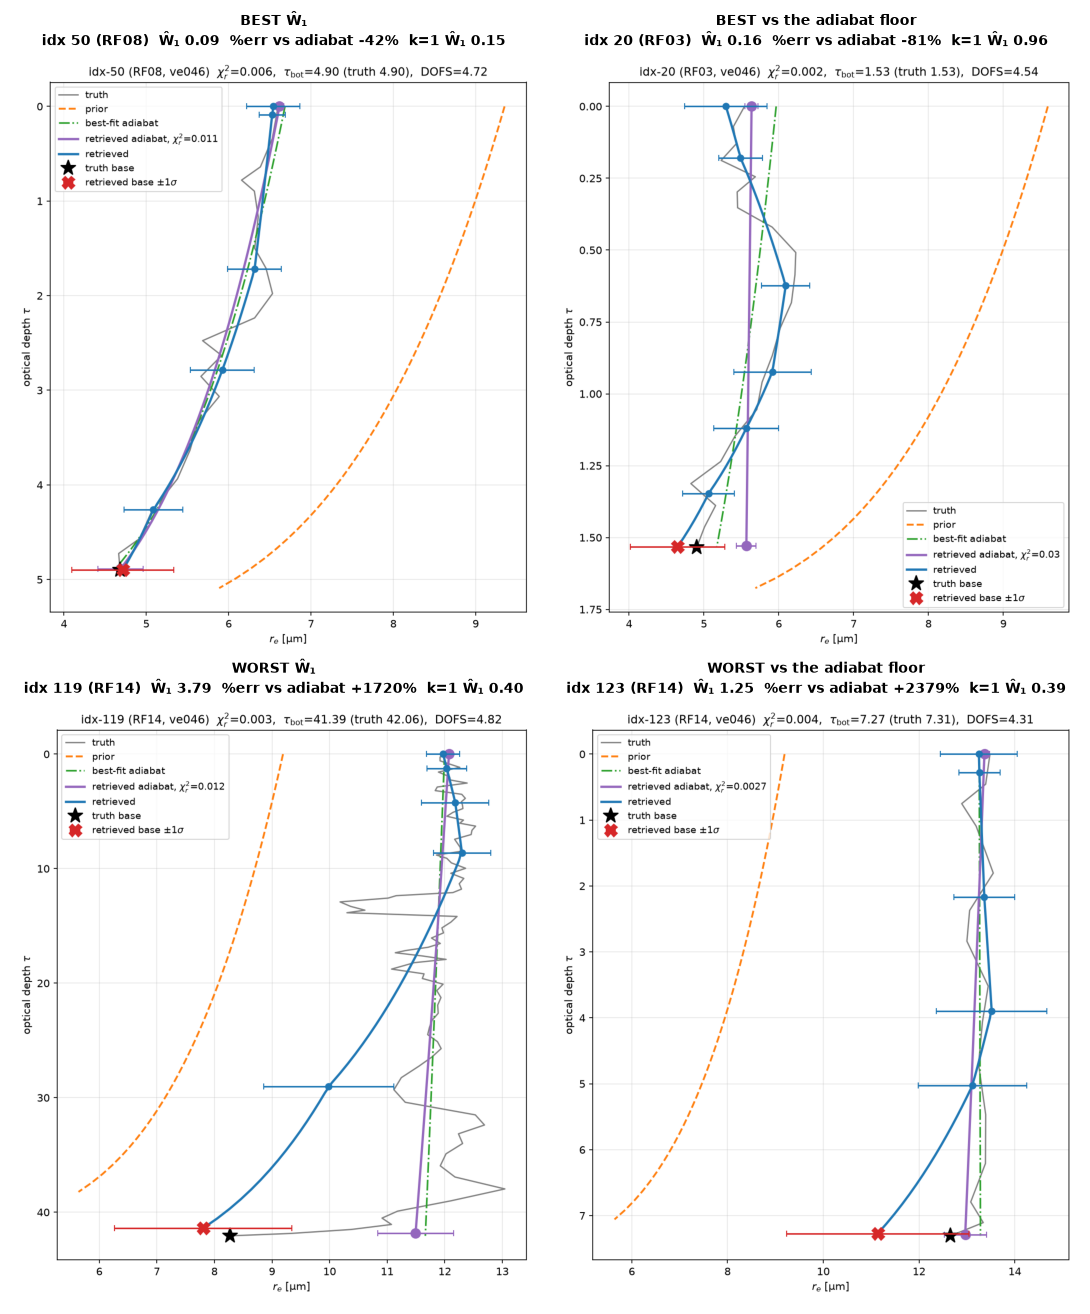

§16 Fig 1 — best and worst retrievals, standard format (green = the truth-fed W1-oracle adiabat; purple dotted with top/base circles = the k=1 RETRIEVED adiabat competitor).


In [4]:
# §16 Fig 1 — best / worst retrieval gallery in the DEFAULT single-profile format
# (scripts/plot_retrieved_profile.py: truth, prior, W1-oracle adiabat, retrieved ±1σ, bases,
# + the k=1 competitor overlay, purple dotted, its χ²ᵣ in the legend).
# Four panels: best Ŵ₁, best vs the adiabat floor, worst Ŵ₁, worst vs the floor — falling back
# to the 2nd-ranked floor pick when it coincides with the Ŵ₁ pick.
if ROWS and CANON_DIR is not None:
    order_pct = np.argsort(PW_FR)
    order_err = np.argsort(PCTERR)
    _k1lab = (lambda i: f'  k=1 Ŵ₁ {PW_K1[i]:.2f}') if K1R else (lambda i: '')
    _lab = lambda i, what: (f"{what}\nidx {A[i]['index']} ({A[i]['flight']})  "
                            f"Ŵ₁ {A[i]['pct_w1']:.2f}  %err vs adiabat {PCTERR[i]:+.0f}%{_k1lab(i)}"
                            + (f"\n[{PROV_FLAG[A[i]['index']]}]" if A[i]['index'] in PROV_FLAG else ''))
    best, worst = order_pct[0], order_pct[-1]
    bf = order_err[0] if A[order_err[0]]['index'] != A[best]['index'] else order_err[1]
    wf = order_err[-1] if A[order_err[-1]]['index'] != A[worst]['index'] else order_err[-2]
    picks = [(A[best]['index'], _lab(best, 'BEST Ŵ₁')),
             (A[bf]['index'], _lab(bf, 'BEST vs the adiabat floor'
                                       + (' (2nd best, dedup)' if bf != order_err[0] else ''))),
             (A[worst]['index'], _lab(worst, 'WORST Ŵ₁')),
             (A[wf]['index'], _lab(wf, 'WORST vs the adiabat floor'
                                       + (' (2nd worst, dedup)' if wf != order_err[-1] else '')))]
    profile_montage(picks, ncol=2)
    print('§16 Fig 1 — best and worst retrievals, standard format (green = the truth-fed W1-oracle '
          'adiabat; purple dotted with top/base circles = the k=1 RETRIEVED adiabat competitor).')
elif ROWS:
    print('(gallery skipped: raw bundle not on this machine)')

### Finding 2 — the free-node retrieval beats the matched adiabatic retrieval; where it loses, it loses small and for identifiable reasons

**The head-to-head** (Fig 2a,b; all 125, promoted records included): ours wins **shape 59 %, LWP 64 %, both 50 %, loses both 27 %**; median $\hat{W}_1$ **0.39 vs 0.49** (median per-profile ratio 0.80 — a 20 % lower shape error against a competitor that shares every input except the model class). Both fit the radiances at the noise floor (median $\chi^2_r$ 0.0029 vs 0.0066), and per-profile difficulty only weakly correlates between the two (Spearman 0.29) — they fail on *different* clouds. (Provenance: idx 57 and idx 119, among the k=1's largest wins, carry pathology flags — FR-side and k=1-side respectively; idx 92, among ours, carries the k=1-side flag.)

**How can the richer model class lose at all?** The free-node state strictly *contains* the adiabat class (the node interpolation is $r_e^5$-linear in $s$, and an adiabat **is** an $r_e^5$-line — every adiabat is exactly representable at any node placement), so under maximum likelihood we could never do worse. But the estimator is regularized MAP, not ML, and three effects allow per-profile losses:

1. **Bias–variance.** The same ~4.4 DOFS (of $p=k{+}2\in[6,9]$) that let us *represent* non-adiabatic structure must be spread over more parameters; the unresolved remainder is filled by the prior and the curvature Tikhonov, which pull toward the *climatology* shape — not toward the nearest adiabat. The k=1 estimator concentrates the same information on 3 parameters and is essentially fully determined (DOFS 2.7–3.0 of 3). When the truth lies inside (or near) the adiabat class, k=1 carries **zero model bias and less variance** — it wins by construction.
2. **The radiance fit does not adjudicate.** Both estimators sit at the noise floor, so the data cannot distinguish them; the within-noise solution manifold is wide for the free-node state (the §15 null space) and only 3-dimensional for the adiabat. For a near-adiabatic truth, the k=1 manifold is *concentrated near the truth*; ours contains the truth but also everything the prior prefers.
3. **The evidence** (Fig 2c): losses concentrate on near-adiabatic truths — Spearman(truth non-adiabaticity, ours/k1 ratio) = **−0.29** (p = 8×10⁻⁴); median truth non-adiabaticity among our losses 0.22 vs 0.28 among wins. And the margins are asymmetric: median **win margin 0.31 $\hat{W}_1$ vs loss margin 0.19** — we lose small where an adiabat was already right, and win big where it is wrong. That *is* the bias–variance trade, resolved in our favor at the population level.

The exemplar is **idx 32**: its radiances are adiabat-consistent to $\chi^2_r$ = 0.004 and the k=1 competitor nails it ($\hat{W}_1$ 0.21) — while our main-pipeline record kinked to $\hat{W}_1$ 4.10, the campaign's worst. Its promoted pathology record (canonical since 2026-07-19) recovers to **1.65** — still a ×8 k=1 win, but the ×20 outlier is gone. The rescue separates the two layers of the failure: the kink *excess* (4.10 → 1.65) was a **Gauss–Newton basin** — released by a 3rd-decimal dither of the τ_bot prior anchor, a pure seed change (Finding 5) — while the residual 1.65 is the **prior sabotage** floor the veto arithmetic below prices: the rescued base still reverts prior-ward, because the truth-like state remains objective-vetoed. The promoted idx 119 record (k=1 pathology flag) is the same story at depth (×9.4, $\hat{W}_1$ 0.40 vs our 3.79 on a truth whose oracle floor is 0.21). Those failures are **ours** (prior-driven, not cloud difficulty). The mirror cases are structured clouds the adiabat cannot represent: **idx 19** (we win ×12; a significance-test member), idx 48/35/77 (×9–10).

**Our two historical worst cases were sabotaged by the prior — and both truths sit at the edge of the climatology.** The MAP cost decomposition (reconstructed from the sidecars; the adiabat is exactly representable on the FR grid, so no re-runs are needed) separates two sabotage modes. For **idx 32** (superseded record) it was a hard **veto** — plus, we now know, a basin on top. The veto arithmetic: the truth-like adiabatic state cost 55.4 in prior penalty *alone*, against that record's total $J$ = 19.6 (data 9.1 + prior 8.4 + curvature 2.0) — no seed can make the optimizer *reach the truth*, because the objective itself vetoes it; its $\chi^2_r$ (0.076, ~26× the population floor) was the visible strain — an operational flag requiring no truth knowledge. **The 2026-07-19 rescue then decomposed the failure by intervention, in two steps**: feeding the true τ_bot into the prior anchor — the treatment that rescued all three k=1 basins — did *not* release idx 32; adding a 3rd-decimal *dither* to that anchor — a pure seed change — did, after which the setup selected a leaner 4-node grid (the kink-hosting $s$=0.86 node dropped) and GN landed at the radiance floor ($\chi^2_r$ 0.0043, $\hat{W}_1$ 1.65; the false significance alarm of Finding 5 cleared). So the kink itself was a **Gauss–Newton basin, not the objective's preference** (our earlier "a seed perturbation cannot fix it" was an overreach — it cannot recover the *truth*, but it escaped the *kink*), while the veto sets the floor of the rescue: the recovered profile still loses ×8 to the k=1 with its base held prior-ward. For **idx 123** it is a soft **null-space steer**: the record and the truth-like state are near-degenerate in total cost (ΔJ ≲ 1, both data terms at the radiance floor), so the data cannot arbitrate and the prior term tips the unobserved base ~1.5 µm off truth — invisible to $\chi^2$ by construction (though the posterior covers it: the truth base sits within ~1σ of the retrieved one); consistently, its 2026-07-19 re-run did not improve it, and the original record stands. The saboteur had opportunity because both truths are **climatological outliers**: idx 32 is the 2nd most prior-distant truth of all 125 ($r_e$-block mean 3.1σ from the leave-one-flight-out climatology; population median 0.7σ) and idx 123 the 10th (2.1σ). Corroboration from the other end: the three most prior-distant truths — idx 57, 32, 49 — are precisely the pathology-promotion set.

**The prior's role differs in kind, not just degree, between the model classes.** The k=1 retrieval is nearly **prior-independent** — its three parameters are almost fully data-determined (DOFS 2.7–3.0 of 3) — so an adiabatic retrieval can get away with an uninformative prior, and the OE framework largely just tags uncertainty estimates onto it. We cannot: for the free-node state the prior (with the curvature penalty) *is* the stabilizer — OE plays the essential role of a Tikhonov regularizer that renders the underdetermined inversion well-posed, and its price is exactly the bias of points 1–3 in the directions the data leave unresolved.

**Does the residual bias at low non-adiabaticity (Fig 2b) indict the node selection?** Only marginally. "Perfect node selection would recognize adiabaticity" requires recognizing it **from radiances**, and Finding 2's own mechanism says radiances can't do it: both model classes fit at the noise floor almost everywhere, so a χ²-parsimony collapse rule would pick the adiabat nearly always and inherit the k=1's numbers (median $\hat{W}_1$ 0.49) in place of ours (0.39) — aggressive collapse is strictly *worse*. The ratio above 1 on the left of Fig 2b is the *premium* of an insurance policy whose *payout* is the ratio below 1 on the right, and the asymmetric margins (median win 0.31 vs loss 0.21 $\hat{W}_1$) price the policy net-positive; trimming the node-count margin would slide along this premium/payout frontier, not escape it. The re-mesh collapses of the pathology treatment are the consistent exception: they were χ²-gated rescues — collapse only where the radiance evidence forced it — which is precisely the regime where data can adjudicate. Adaptive model-order reduction therefore stays a rescue mechanism, not a default.

<>:25: SyntaxWarning: invalid escape sequence '\h'
<>:26: SyntaxWarning: invalid escape sequence '\h'
<>:38: SyntaxWarning: invalid escape sequence '\h'
<>:39: SyntaxWarning: invalid escape sequence '\h'
<>:63: SyntaxWarning: invalid escape sequence '\h'
<>:25: SyntaxWarning: invalid escape sequence '\h'
<>:26: SyntaxWarning: invalid escape sequence '\h'
<>:38: SyntaxWarning: invalid escape sequence '\h'
<>:39: SyntaxWarning: invalid escape sequence '\h'
<>:63: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipykernel_205740/248104445.py:25: SyntaxWarning: invalid escape sequence '\h'
  axA.set(xscale='log', yscale='log', xlabel='$\hat{W}_1$, k=1 retrieved adiabat',
/tmp/ipykernel_205740/248104445.py:26: SyntaxWarning: invalid escape sequence '\h'
  ylabel='$\hat{W}_1$, ours (free-node)',
/tmp/ipykernel_205740/248104445.py:38: SyntaxWarning: invalid escape sequence '\h'
  xlabel='truth non-adiabaticity: $\hat{W}_1$ of the ORACLE adiabat',
/tmp/ipykernel_205740/248104445.py:39: SyntaxW

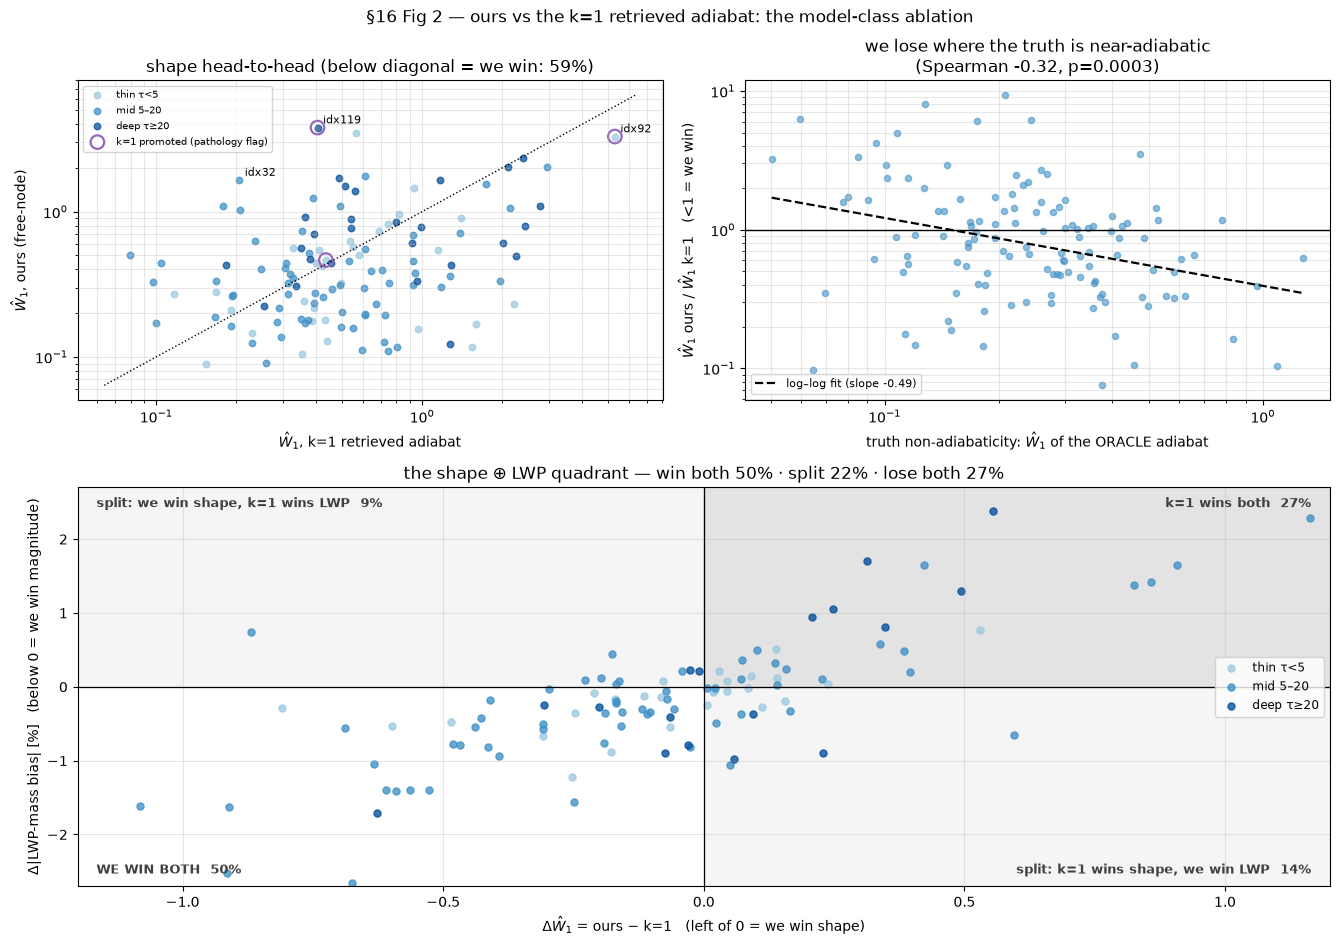

  (quadrant axes clipped at the 90th percentile for detail: 18 points beyond view — the usual deep/pathology cases; quadrant percentages count ALL 125)


In [5]:
# §16 Fig 2 — the model-class ablation, per profile. Top: (a) Ŵ₁ head-to-head (below the
# diagonal = ours wins); (b) WHY we lose: the ours/k1 error ratio vs the truth's own
# non-adiabaticity (losses cluster where the truth is near-adiabatic — Finding 2), with the
# log-log best-fit line. Bottom (large): the shape⊕LWP quadrant — grey regions = k=1 wins
# something (darker = both), white = we win both; axes clipped to the 90th percentile for
# detail (off-view count printed). Regime = ordinal blues (light thin → dark deep).
if ROWS and K1R:
    import scipy.stats as _sps
    fig = plt.figure(figsize=(13.5, 9.6))
    gs = fig.add_gridspec(2, 2, height_ratios=[1.0, 1.25])
    axA = fig.add_subplot(gs[0, 0]); axB = fig.add_subplot(gs[0, 1])
    axQ = fig.add_subplot(gs[1, :])
    cols = ['#9ecae1', '#4292c6', '#08519c']            # ordinal: thin → deep
    for (lab, m), c in zip(REGIMES, cols):
        axA.scatter(PW_K1[m], PW_FR[m], s=22, alpha=.75, color=c, label=lab)
    _pr = np.array([r['index'] in K1_PROV_FLAG for r in A])
    axA.scatter(PW_K1[_pr], PW_FR[_pr], s=95, facecolors='none',
                edgecolors='tab:purple', lw=1.6, label='k=1 promoted (pathology flag)')
    _l = [min(PW_K1.min(), PW_FR.min()) * .8, max(PW_K1.max(), PW_FR.max()) * 1.2]
    axA.plot(_l, _l, 'k:', lw=1)
    for i, r in enumerate(A):
        if r['index'] in (32, 92, 119):
            axA.annotate(f"idx{r['index']}", (PW_K1[i], PW_FR[i]), fontsize=8,
                         xytext=(4, 3), textcoords='offset points')
    axA.set(xscale='log', yscale='log', xlabel='$\hat{W}_1$, k=1 retrieved adiabat',
            ylabel='$\hat{W}_1$, ours (free-node)',
            title=f'shape head-to-head (below diagonal = we win: {np.mean(WIN_W):.0%})')
    axA.legend(fontsize=7.5, loc='upper left'); axA.grid(alpha=.3, which='both')
    _rr = PW_FR / PW_K1
    axB.scatter(PW_ORC, _rr, s=20, alpha=.6, color='#4292c6')
    axB.axhline(1.0, color='k', lw=1.0)
    _sl, _ic = np.polyfit(np.log(PW_ORC), np.log(_rr), 1)
    _xs = np.geomspace(PW_ORC.min(), PW_ORC.max(), 50)
    axB.plot(_xs, np.exp(_ic) * _xs ** _sl, 'k--', lw=1.6,
             label=f'log–log fit (slope {_sl:+.2f})')
    _sr = _sps.spearmanr(PW_ORC, _rr)
    axB.set(xscale='log', yscale='log',
            xlabel='truth non-adiabaticity: $\hat{W}_1$ of the ORACLE adiabat',
            ylabel='$\hat{W}_1$ ours / $\hat{W}_1$ k=1   (<1 = we win)',
            title=f'we lose where the truth is near-adiabatic\n'
                  f'(Spearman {_sr.statistic:+.2f}, p={_sr.pvalue:.1g})')
    axB.grid(alpha=.3, which='both'); axB.legend(fontsize=8, loc='lower left')
    dx = PW_FR - PW_K1                                  # <0 = we win shape
    dy = np.abs(MB_FR) - np.abs(MB_K1)                  # <0 = we win LWP magnitude
    _xm = np.percentile(np.abs(dx), 90); _ym = np.percentile(np.abs(dy), 90)
    axQ.set_xlim(-_xm, _xm); axQ.set_ylim(-_ym, _ym)
    # who-wins-where shading: any grey = k=1 wins something; darker = k=1 wins both
    axQ.fill_between([0, _xm], 0, _ym, color='0.5', alpha=.22, zorder=0)
    axQ.fill_between([-_xm, 0], 0, _ym, color='0.5', alpha=.08, zorder=0)
    axQ.fill_between([0, _xm], -_ym, 0, color='0.5', alpha=.08, zorder=0)
    _q = lambda mx, my: np.mean(mx & my)
    for x, y, ha, va, t in [
            (-.97 * _xm, -.95 * _ym, 'left', 'bottom', f'WE WIN BOTH  {_q(dx < 0, dy < 0):.0%}'),
            (.97 * _xm, .95 * _ym, 'right', 'top', f'k=1 wins both  {_q(dx > 0, dy > 0):.0%}'),
            (-.97 * _xm, .95 * _ym, 'left', 'top',
             f'split: we win shape, k=1 wins LWP  {_q(dx < 0, dy > 0):.0%}'),
            (.97 * _xm, -.95 * _ym, 'right', 'bottom',
             f'split: k=1 wins shape, we win LWP  {_q(dx > 0, dy < 0):.0%}')]:
        axQ.text(x, y, t, fontsize=9, ha=ha, va=va, color='0.25', fontweight='bold')
    for (lab, m), c in zip(REGIMES, cols):
        axQ.scatter(dx[m], dy[m], s=26, alpha=.8, color=c, label=lab)
    axQ.axhline(0, color='k', lw=.9); axQ.axvline(0, color='k', lw=.9)
    axQ.set(xlabel='Δ$\hat{W}_1$ = ours − k=1   (left of 0 = we win shape)',
            ylabel='Δ|LWP-mass bias| [%]   (below 0 = we win magnitude)',
            title=f'the shape ⊕ LWP quadrant — win both {np.mean(WIN_W & WIN_L):.0%} · split '
                  f'{np.mean(WIN_W ^ WIN_L):.0%} · lose both {np.mean(~WIN_W & ~WIN_L):.0%}')
    axQ.grid(alpha=.3); axQ.legend(fontsize=8.5, loc='center right')
    _out = int(np.sum((np.abs(dx) > _xm) | (np.abs(dy) > _ym)))
    fig.suptitle('§16 Fig 2 — ours vs the k=1 retrieved adiabat: the model-class ablation',
                 fontsize=12)
    fig.tight_layout(); plt.show()
    print(f'  (quadrant axes clipped at the 90th percentile for detail: {_out} points beyond view '
          '— the usual deep/pathology cases; quadrant percentages count ALL 125)')
elif ROWS:
    print('(head-to-head skipped: k=1 rows unavailable)')

### Finding 3 — the advantage lives where the measurement penetrates: decisive mid-τ, modest thin, a statistical tie for deep clouds

**The regime head-to-heads** (Fig 3; table in the headline cell): **mid (5≤τ<20, n=66)** is decisively ours — win shape 65 %, win both 55 %, median $\hat{W}_1$ 0.32 vs 0.41 (paired Wilcoxon p = 0.007). **Thin (τ<5, n=32)** is a modest, not-significant edge — win shape 53 %, win both 50 %, median 0.37 vs 0.47, p = 0.10 (small-n and near-adiabatic truths; the promoted idx-92 record moved this bin our way). **Deep (τ≥20, n=27) is a statistical tie by the paired test**: win shape 52 %, Wilcoxon p = 0.95, with the *lose-both* fraction (37 %) at its population peak; the unpaired medians read 0.77 vs 0.56 — the promoted idx 119 record (k=1 pathology flag) pulled the k=1 deep median below ours, so if anything the deep regime leans to the adiabat marginally. (This retires the deep-pessimistic reading from the interim truth-fed compromise rung, which was oracle-strong at depth by construction.)

**Why the deep tie — two different failure modes, one error level.** Both retrievals land far above the oracle floor deep ($\hat{W}_1$ 0.77/0.56 vs floor 0.22; median %err vs floor +197 %/+179 %). But they get there differently:
* the **k=1** state stays essentially fully determined at depth (DOFS 2.73/3; $r_{\rm base}$ DOFS 0.74) — its deep error is **model bias**: the truth's sub-veil departures from the adiabat are radiance-invisible, so the confident adiabatic extrapolation is wrong wherever the truth bends;
* **ours** is **prior reversion**: the deep nodes are prior-dominated ($r_{\rm base}$ DOFS 0.10 deep vs 0.30 thin), so below the veil the profile relaxes to the climatology shape (§15 Finding 3's information pump reaches a median 15.3 τ in thick clouds — short of bases at τ≥20).

A fully-determined wrong model and an underdetermined flexible one meet at the same number: the deep-cloud error is an **observing-system property (the veiled core), not an estimator property** — no model-class choice recovers what no radiance constrains. Consistently, the *un-normalized* skill remains thickness-flat (the retired "thin clouds are retrieved best" trend was the support-scaling artifact of raw $W_1$: $r(\log\tau_{\rm bot}, W_1^{\rm raw})$ = +0.68 vs $r(\log\tau_{\rm bot}, \hat{W}_1)$ = +0.18, Fig 3a) — only the deepest bin degrades, for both model classes.

**Implications.** (i) For deep-cloud *shape*, the adiabatic assumption costs nothing measurable — but it is not free elsewhere: we still edge deep LWP (52 %), and k=1's fully-determined posterior is confidently wrong at depth, where ours at least widens toward the prior (Finding 8). (ii) The free-node advantage is a **thin/mid-cloud claim** — which is where the population lives (98/125). (iii) More deep information must come from the observing system (angles + absorbing bands, §15 Corollary 3), not from the estimator.

<>:30: SyntaxWarning: invalid escape sequence '\h'
<>:30: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipykernel_205740/68941717.py:30: SyntaxWarning: invalid escape sequence '\h'
  ax[0].set(xscale='log', yscale='log', xlabel=r'true $\tau_{bot}$', ylabel='$\hat{W}_1$',


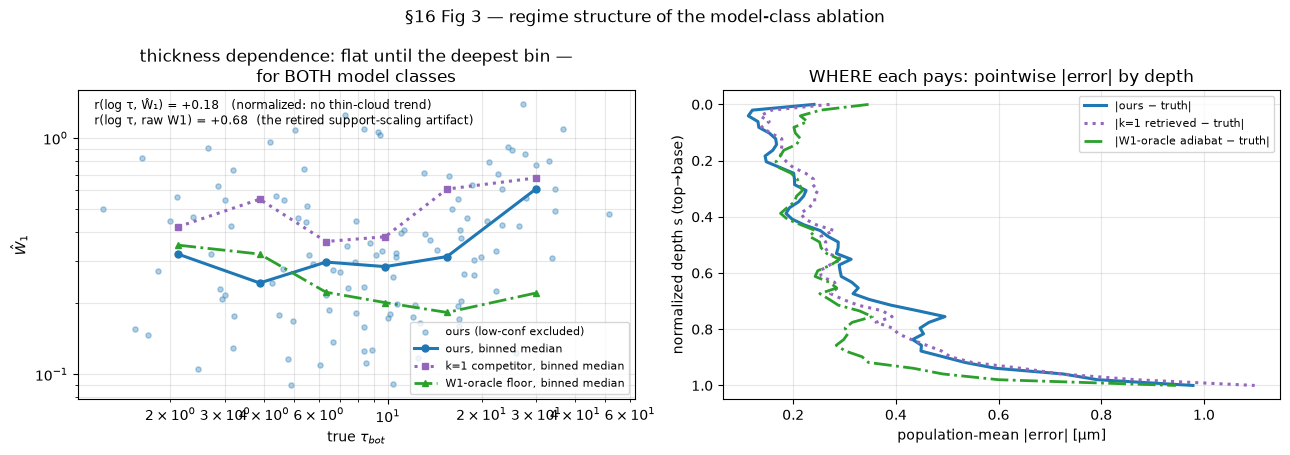

In [6]:
# §16 Fig 3 — regime structure. (a) Ŵ₁ vs τ_bot: ours (cleaned scatter) with binned medians
# for ours / k=1 / oracle — skill is thickness-flat under the canonical normalized metric
# (the raw-W1 "thin best" trend was a support-scaling artifact, retired); only the deepest bin
# degrades, for BOTH model classes. (b) population-mean |error| vs normalized depth: WHERE each
# curve pays — top vs the prior-reverted / bias-extrapolated deep cloud.
if ROWS and K1R:
    LC = {(m[0], m[1]) for m in SUMMARY['flags']['low_confidence']['members']}
    keep = np.array([(r['index'], r['config']) not in LC for r in A])
    edges = np.array([1.5, 3, 5, 8, 12, 20, 45.0]); ctr = np.sqrt(edges[:-1] * edges[1:])
    _bmed = lambda yy, kp: [np.median(yy[kp & (TB >= lo) & (TB < hi)])
                            if np.any(kp & (TB >= lo) & (TB < hi)) else np.nan
                            for lo, hi in zip(edges[:-1], edges[1:])]
    # identity colors match the standard profile plot (user rule 2026-07-18): ours = tab:blue
    # solid, k=1 = tab:purple dotted, oracle adiabat = tab:green dash-dot — everywhere.
    fig, ax = plt.subplots(1, 2, figsize=(13, 4.6))
    ax[0].scatter(TB[keep], PW_FR[keep], s=14, alpha=.35, color='tab:blue',
                  label='ours (low-conf excluded)')
    _all = np.ones(len(A), bool)
    ax[0].plot(ctr, _bmed(PW_FR, keep), color='tab:blue', ls='-', marker='o', lw=2.2, ms=5,
               label='ours, binned median', zorder=5)
    ax[0].plot(ctr, _bmed(PW_K1, _all), color='tab:purple', ls=':', marker='s', lw=2.2, ms=5,
               label='k=1 competitor, binned median', zorder=5)
    ax[0].plot(ctr, _bmed(PW_ORC, _all), color='tab:green', ls='-.', marker='^', lw=2, ms=5,
               label='W1-oracle floor, binned median', zorder=5)
    _rn = np.corrcoef(np.log(TB[keep]), PW_FR[keep])[0, 1]
    _ra = np.corrcoef(np.log(TB[keep]), (PW_FR * TB / 100.0)[keep])[0, 1]
    ax[0].annotate(f'r(log τ, Ŵ₁) = {_rn:+.2f}   (normalized: no thin-cloud trend)\n'
                   f'r(log τ, raw W1) = {_ra:+.2f}  (the retired support-scaling artifact)',
                   (.03, .89), xycoords='axes fraction', fontsize=8.5)
    ax[0].set(xscale='log', yscale='log', xlabel=r'true $\tau_{bot}$', ylabel='$\hat{W}_1$',
              title='thickness dependence: flat until the deepest bin —\nfor BOTH model classes')
    ax[0].grid(alpha=.3, which='both'); ax[0].legend(fontsize=8, loc='lower right')
    if CANON_DIR is not None and K1_DIR is not None:
        SD = eO = eA = eK = None; n = 0
        for r in A:
            d = np.load(CANON_DIR / f"{r['index']}_A.npz", allow_pickle=True)
            d1 = np.load(K1_DIR / f"{r['index']}_A.npz", allow_pickle=True)
            s = np.asarray(d['s_dense'], float); SD = s
            tr = np.asarray(d['re_truth_dense'], float)
            eO = (0 if eO is None else eO) + np.abs(np.asarray(d['re_ours_dense'], float) - tr)
            eA = (0 if eA is None else eA) + np.abs(np.asarray(d['re_adia_dense'], float) - tr)
            eK = (0 if eK is None else eK) + np.abs(np.asarray(d1['re_ours_dense'], float) - tr)
            n += 1
        ax[1].plot(eO / n, SD, color='tab:blue', ls='-', lw=2.2, label='|ours − truth|')
        ax[1].plot(eK / n, SD, color='tab:purple', ls=':', lw=2.2, label='|k=1 retrieved − truth|')
        ax[1].plot(eA / n, SD, color='tab:green', ls='-.', lw=2, label='|W1-oracle adiabat − truth|')
        ax[1].invert_yaxis(); ax[1].grid(alpha=.3); ax[1].legend(fontsize=8)
        ax[1].set(xlabel='population-mean |error| [µm]', ylabel='normalized depth s (top→base)',
                  title='WHERE each pays: pointwise |error| by depth')
    else:
        ax[1].set_axis_off(); ax[1].text(.05, .5, 'error-vs-depth needs both raw bundles', fontsize=9)
    fig.suptitle('§16 Fig 3 — regime structure of the model-class ablation', fontsize=12)
    fig.tight_layout(); plt.show()

### Finding 4 — the truth-fed oracle floor is unreachable for any radiance-driven method; we approach/beat it exactly where the truth is non-adiabatic

The k=1 campaign calibrates the floor's reachability: the best adiabatic **retrieval** lands **+81 %** above the floor its own model class defines (we land +60 %) — so the oracle comparisons below measure distance to an *unreachable* reference, not a deficit against a feasible method. (The k=1's nominal 4.8 % floor-"win rate" is a metric artifact, not class superiority: those six wins are hairline margins bought by the retrieval's *support freedom* — under $W_1$ a slightly-off $\tau_{\rm bot}$ occasionally fits the truth's mass CDF better than the exact support does; on the shared support the oracle dominates all six, and against a support-free oracle refit the k=1 win rate is exactly 0 % — verified in the headline cell.)

The floor-relative error is strongly anti-correlated with the truth's own non-adiabaticity ($r$ of logs = **−0.50**, Fig 4a): for near-adiabatic truths the oracle is nearly perfect and *cannot* be beaten (trailing it there costs ~nothing absolutely), while for the most non-adiabatic clouds the retrieval wins outright (best cases idx 20/35/19: %err −81/−79/−69). Pointwise (Fig 3b), the free-node state beats even the oracle at the **cloud top** (mean |err| 0.15 vs 0.22 µm for s<0.2) and trails below s≈0.6 with the base spike — the depth-shielding limit, unchanged.

<>:21: SyntaxWarning: invalid escape sequence '\h'
<>:27: SyntaxWarning: invalid escape sequence '\h'
<>:21: SyntaxWarning: invalid escape sequence '\h'
<>:27: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipykernel_205740/3929687851.py:21: SyntaxWarning: invalid escape sequence '\h'
  ax[0].set(xscale='log', xlabel='truth non-adiabaticity: $\hat{W}_1$ of the ORACLE adiabat',
/tmp/ipykernel_205740/3929687851.py:27: SyntaxWarning: invalid escape sequence '\h'
  title='regime: the floor-relative error vs thickness\n(circled = worst-decile $\hat{W}_1$)')


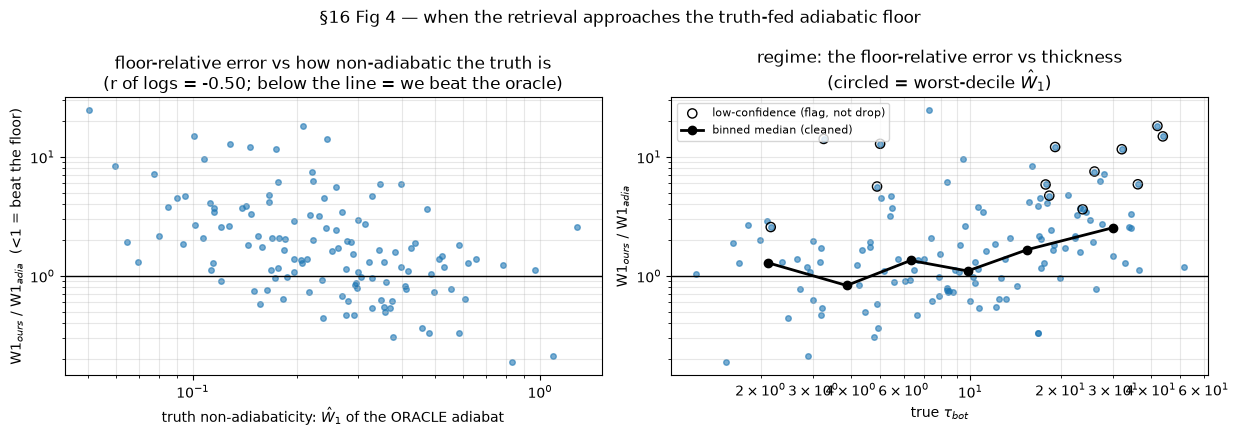

  win rate vs the floor: 29.6% overall; 33.0% excluding low-confidence


In [7]:
# §16 Fig 4 — the truth-fed oracle floor: WHEN do we approach/beat it? (a) W1_ours/W1_adia vs
# the truth's own non-adiabaticity (Ŵ₁ of the oracle adiabat); (b) the same ratio vs τ_bot
# (regime + low-confidence + binned medians). Ratio (log scale) below 1 = we beat the oracle.
if ROWS:
    LC = {(m[0], m[1]) for m in SUMMARY['flags']['low_confidence']['members']}
    lc_m = np.array([(r['index'], r['config']) in LC for r in A])
    fig, ax = plt.subplots(1, 2, figsize=(12.5, 4.4))
    ax[0].scatter(PW_ORC, RATIO, s=16, alpha=.6, color='tab:blue')
    ax[1].scatter(TB, RATIO, s=16, alpha=.6, color='tab:blue')
    ax[1].scatter(TB[lc_m], RATIO[lc_m], s=44, facecolors='none', edgecolors='k',
                  label='low-confidence (flag, not drop)')
    edges = np.array([1.5, 3, 5, 8, 12, 20, 45.0]); ctr = np.sqrt(edges[:-1] * edges[1:])
    keep = ~lc_m
    med = [np.median(RATIO[keep & (TB >= lo) & (TB < hi)])
           if np.any(keep & (TB >= lo) & (TB < hi)) else np.nan
           for lo, hi in zip(edges[:-1], edges[1:])]
    ax[1].plot(ctr, med, 'k-o', lw=2, ms=6, label='binned median (cleaned)', zorder=5)
    for a in ax:
        a.axhline(1.0, color='k', lw=1.0); a.set_yscale('log'); a.grid(alpha=.3, which='both')
    _r = np.corrcoef(np.log(PW_ORC), np.log(RATIO))[0, 1]
    ax[0].set(xscale='log', xlabel='truth non-adiabaticity: $\hat{W}_1$ of the ORACLE adiabat',
              ylabel='W1$_{ours}$ / W1$_{adia}$  (<1 = beat the floor)',
              title=f'floor-relative error vs how non-adiabatic the truth is\n'
                    f'(r of logs = {_r:+.2f}; below the line = we beat the oracle)')
    ax[1].legend(fontsize=8, loc='upper left')
    ax[1].set(xscale='log', xlabel=r'true $\tau_{bot}$', ylabel='W1$_{ours}$ / W1$_{adia}$',
              title='regime: the floor-relative error vs thickness\n(circled = worst-decile $\hat{W}_1$)')
    fig.suptitle('§16 Fig 4 — when the retrieval approaches the truth-fed adiabatic floor',
                 fontsize=12)
    fig.tight_layout(); plt.show()
    print(f'  win rate vs the floor: {np.mean(RATIO < 1):.1%} overall; '
          f'{np.mean(RATIO[~lc_m] < 1):.1%} excluding low-confidence')

### Finding 5 — loud χ²ᵣ alarms need a re-solve before they mean "rejection": all three were optimization basins; the graded χ²ᵣ still corroborates the significance test

**No hard class rejection survives.** The original campaign produced three structural misfits ($\chi^2_r$ = 49.8/35.7/16.3 at idx 92/8/119, the latter two inverted). Re-run under the pathology treatment (true-τ_bot-fed prior mean; identical radiances), **all three re-fit within the campaign's own range** — idx 8/119 at $\chi^2_r$ = 0.0015/0.012 with physical, non-inverted adiabats, and idx 92 at $\chi^2_r$ = 0.16, *inside* the campaign's mild-elevation tail (rank #3, between idx 49's 0.20 and idx 46's 0.16). The loud alarms were **Gauss–Newton basins, not class rejections**, and the treatment changed only the prior: even the nearly prior-independent class is prior-*path*-sensitive — the prior barely weights its optimum but still steers the solver's basin. All three promoted records are canonical (flagged). **The idx 92 promotion is deliberately truth-blind**: its de-inverted fit agrees *less* well with the genuinely inverted truth than the rejected fit did ($\hat{W}_1$ 1.50 → 5.30, incidentally handing us that head-to-head) — the $\chi^2_r$=50 record had matched the truth's inversion by accident while missing the radiances ×200 worse than any other cloud, and keeping it for its truth agreement would have been selection on the answer. What remains at idx 92 is a **graded, real residual misfit** ($\chi^2_r$ ×24 the campaign median, on the cloud our posterior test ranks most non-adiabatic) — the strongest member of the corroboration tail below, not a hard rejection. Operationally: an adiabatic pipeline's $\chi^2_r$ is still a non-adiabaticity detector, but its **loud alarms must be confirmed by a prior-nudged re-solve** before being read as model-class failure — all three of ours recanted on the re-solve.

**The basin fragility is class-agnostic — the FR side has its own demonstrated case.** idx 32's kink record (our worst, $\hat{W}_1$ 4.10) sat in a GN basin that the true-τ_bot prior treatment alone could *not* escape — only adding a 3rd-decimal *dither* to the anchor, a pure seed change, did ($\chi^2_r$ 0.076 → 0.0043, $\hat{W}_1$ 1.65; Finding 2 separates this basin excess from the prior-sabotage floor beneath it). The common tell across all four cases, both model classes, was $\chi^2_r$ **strain** well above the population floor (26×–17 000×); the common cure was a re-solve along a perturbed optimization path. No single-run record should be read as its class's optimum where $\chi^2_r$ is elevated — a fragility caveat that applies to this campaign's remaining strained fits too.

**The corroboration** (Fig 5c). The §16 significance test asks a *state-space* question (is any adiabat inside our 70 % posterior?); the k=1 $\chi^2_r$ asks the *radiance-space* one (can an adiabat fit the data?). They agree at the population level — the significantly-non-adiabatic members' median k=1 $\chi^2_r$ is **×12** the rest (0.065 vs 0.0054; Mann–Whitney p = 9.2×10⁻¹¹) — and each promotion *strengthened* the agreement (the basin artifacts were the largest χ²-only outliers, and the promoted FR idx-32 record removed a false-alarm member — below). The graded corroboration lives in the mild-elevation tail ($\chi^2_r$ ~ 0.12–0.24: idx 14/49/92/46/5/52), so it does not hinge on any loud alarm. The robust intersection: **{5, 14, 23, 46, 52, 92}**.

**Honesty in both directions.** idx 32's significance flag was a **false alarm — now demonstrated by intervention**: its radiances are adiabat-consistent ($\chi^2_r$ = 0.004), so the flag had fired on *our own retrieval error* (the basin kink, Finding 2), and with the promoted basin-escaped record the flag **clears** ($d^2/\chi^2_{0.70}$ = 0.12, deep inside the posterior) — exactly what the under-dispersed-posterior reading predicted (Finding 8). Conversely the basin artifacts (idx 8/92/119) were loud in radiance space while the posterior test stayed correctly quiet or graded. Each diagnostic's blind spot is the other's detection — use both.

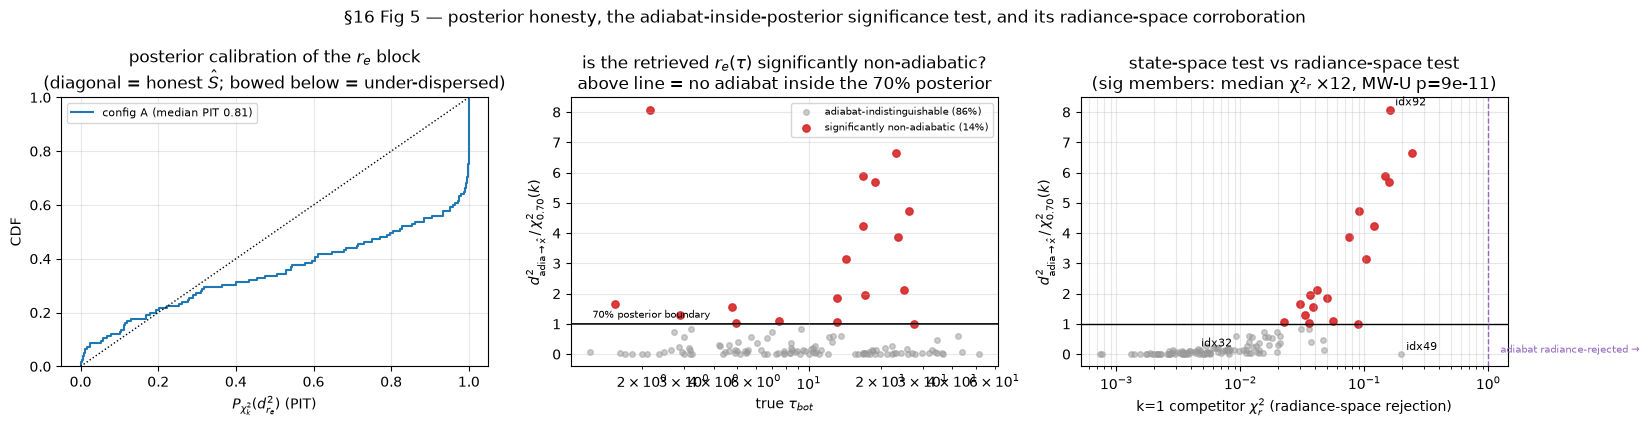

  thin τ<5   n= 32: significantly non-adiabatic  16%
  mid 5–20   n= 66: significantly non-adiabatic  12%
  deep τ≥20  n= 27: significantly non-adiabatic  19%
  overall: 14% significant at 70% — for the other 86% an adiabat sits inside the 70% posterior (adiabat-compatible at our uncertainty)
  robust intersection (sig70 ∧ k=1 χ²ᵣ>0.1): [5, 14, 23, 46, 52, 92]
  (NB the k=2 give-up grids idx 49/57 are adiabat-representable by construction)


In [8]:
# §16 Fig 5 — posterior honesty + non-adiabaticity, three views. (a) PIT of d²_re under χ²_k
# (diagonal = honest Ŝ; Finding 8). (b) the significance test: the closest adiabat to our
# estimate x̂ in units of the 70% posterior ellipsoid (above 1 = no adiabat inside the 70%
# posterior; threshold per user 2026-07-15, linear y — clustering toward 0 is itself the
# message). (c) the radiance-space corroboration: that state-space ratio vs the k=1 χ²ᵣ.
if ROWS:
    from scipy import stats as sst
    CONF = 0.70
    kk = _g(A, 'k').astype(int)
    d2 = _g(A, 'd2_re')
    pit = np.array([sst.chi2.cdf(d, k) for d, k in zip(d2, kk)])
    thr = np.array([sst.chi2.ppf(CONF, k) for k in kk])
    ratio70 = _g(A, 'd2_adia_xhat') / thr
    sig = ratio70 > 1.0
    ncol = 3 if K1R else 2
    fig, ax = plt.subplots(1, ncol, figsize=(5.2 * ncol + 1, 4.3))
    ax[0].ecdf(pit[np.isfinite(pit)], color='tab:blue', label=f'config A (median PIT {np.nanmedian(pit):.2f})')
    ax[0].plot([0, 1], [0, 1], 'k:', lw=1)
    ax[0].set(xlabel=r'$P_{\chi^2_k}(d^2_{r_e})$ (PIT)', ylabel='CDF',
              title='posterior calibration of the $r_e$ block\n(diagonal = honest $\\hat S$; bowed below = under-dispersed)')
    ax[0].legend(fontsize=8); ax[0].grid(alpha=.3)
    ax[1].scatter(TB[~sig], ratio70[~sig], s=16, alpha=.5, color='0.6',
                  label=f'adiabat-indistinguishable ({(~sig).mean():.0%})')
    ax[1].scatter(TB[sig], ratio70[sig], s=28, alpha=.9, color='C3',
                  label=f'significantly non-adiabatic ({sig.mean():.0%})')
    ax[1].axhline(1.0, color='k', lw=1.3, zorder=1)
    ax[1].text(TB.min() * 1.02, 1.12, f'{CONF:.0%} posterior boundary', fontsize=7.5, va='bottom')
    ax[1].set(xscale='log', xlabel=r'true $\tau_{bot}$',
              ylabel=fr'$d^2_{{\rm adia\to\hat{{x}}}}\,/\,\chi^2_{{{CONF:.2f}}}(k)$',
              title='is the retrieved $r_e(\\tau)$ significantly non-adiabatic?\n'
                    f'above line = no adiabat inside the {CONF:.0%} posterior')
    ax[1].grid(alpha=.3); ax[1].legend(fontsize=7.5, loc='upper right')
    if K1R:
        ax[2].scatter(CHI2_K1[~sig], ratio70[~sig], s=16, alpha=.5, color='0.6')
        ax[2].scatter(CHI2_K1[sig], ratio70[sig], s=28, alpha=.9, color='C3')
        ax[2].axhline(1.0, color='k', lw=1.0); ax[2].axvline(1.0, color='tab:purple', lw=1.0, ls='--')
        ax[2].text(1.25, .05, 'adiabat radiance-rejected →', fontsize=7.5, color='tab:purple')
        for i, r in enumerate(A):
            if r['index'] in (92, 32, 49):
                ax[2].annotate(f"idx{r['index']}", (CHI2_K1[i], ratio70[i]), fontsize=8,
                               xytext=(4, 3), textcoords='offset points')
        _mw = sst.mannwhitneyu(CHI2_K1[sig], CHI2_K1[~sig])
        ax[2].set(xscale='log', xlabel=r'k=1 competitor $\chi^2_r$ (radiance-space rejection)',
                  ylabel=fr'$d^2_{{\rm adia\to\hat{{x}}}}\,/\,\chi^2_{{{CONF:.2f}}}(k)$',
                  title='state-space test vs radiance-space test\n'
                        f'(sig members: median χ²ᵣ ×'
                        f'{np.median(CHI2_K1[sig]) / np.median(CHI2_K1[~sig]):.0f}, '
                        f'MW-U p={_mw.pvalue:.1g})')
        ax[2].grid(alpha=.3, which='both')
    fig.suptitle('§16 Fig 5 — posterior honesty, the adiabat-inside-posterior significance test, '
                 'and its radiance-space corroboration', fontsize=12)
    fig.tight_layout(); plt.show()
    for lab, m in REGIMES:
        print(f'  {lab:10s} n={int(m.sum()):>3}: significantly non-adiabatic {sig[m].mean():>4.0%}')
    print(f'  overall: {sig.mean():.0%} significant at {CONF:.0%} — for the other {1 - sig.mean():.0%} '
          f'an adiabat sits inside the {CONF:.0%} posterior (adiabat-compatible at our uncertainty)')
    if K1R:
        print(f'  robust intersection (sig70 ∧ k=1 χ²ᵣ>0.1): '
              f'{sorted(r["index"] for i, r in enumerate(A) if sig[i] and CHI2_K1[i] > 0.1)}')
    print('  (NB the k=2 give-up grids idx 49/57 are adiabat-representable by construction)')

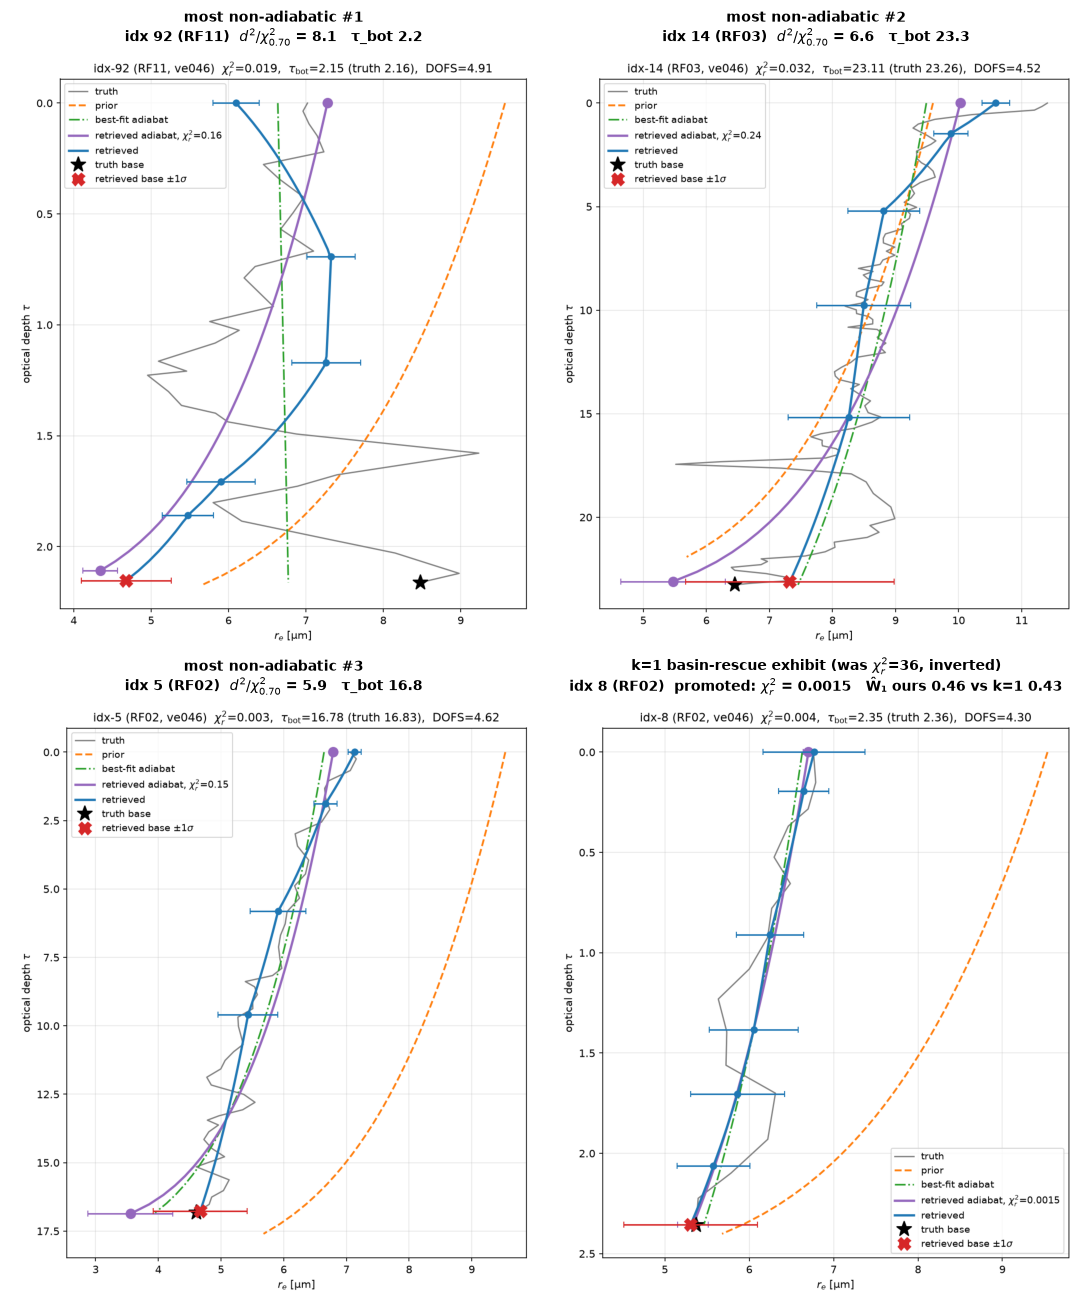

§16 Fig 5b — the most significantly non-adiabatic clouds (posterior test) and the idx-8 basin-rescue exhibit (promoted record), standard format.


In [9]:
# §16 Fig 5b — the three most significantly non-adiabatic retrievals + the idx-8 basin-rescue
# exhibit (its ORIGINAL k=1 record was χ²ᵣ=36 and inverted; the promoted pathology-treatment
# record shown here fits at χ²ᵣ=0.0015 — Finding 5), in the DEFAULT single-profile format
# (k=1 overlay on every panel).
if ROWS and CANON_DIR is not None:
    from scipy import stats as sst
    kk = _g(A, 'k').astype(int)
    ratio70 = _g(A, 'd2_adia_xhat') / np.array([sst.chi2.ppf(0.70, k) for k in kk])
    top3 = np.argsort(ratio70)[-3:][::-1]
    picks = [(A[i]['index'],
              f"most non-adiabatic #{j + 1}\nidx {A[i]['index']} ({A[i]['flight']})  "
              f"$d^2/\\chi^2_{{0.70}}$ = {ratio70[i]:.1f}   τ_bot {TB[i]:.1f}")
             for j, i in enumerate(top3)]
    if K1R:
        i8 = [i for i, r in enumerate(A) if r['index'] == 8][0]
        picks.append((8, f"k=1 basin-rescue exhibit (was $\\chi^2_r$=36, inverted)\nidx 8 "
                         f"({A[i8]['flight']})  promoted: $\\chi^2_r$ = {CHI2_K1[i8]:.2g}   "
                         f"Ŵ₁ ours {PW_FR[i8]:.2f} vs k=1 {PW_K1[i8]:.2f}"))
    profile_montage(picks, ncol=2)
    print('§16 Fig 5b — the most significantly non-adiabatic clouds (posterior test) and the '
          'idx-8 basin-rescue exhibit (promoted record), standard format.')

### Finding 6 — $\tau_{\rm bot}$ is retrieved essentially perfectly by both model classes (non-contentious)

Median $|$relative error$|$: **0.15 %** ours (signed −0.12 %) and **0.26 %** for the k=1 competitor; p90 under 0.7 % for both (headline table). The worst cases are exactly the already-flagged records, not new pathologies: ours maxes at 3.2 % on idx 49 (a pathology-3 provenance record, k=2 give-up grid), then 2.0 % on idx 57; the k=1 competitor maxes at 3.3 % on idx 61, then 2.4 % on idx 92 — the residual-misfit case (Finding 5), whose promoted record recovered τ_bot from the 6.3 % its hard-rejected original had corrupted (the promoted idx 8/119 records likewise recover to 0.1 %/0.6 %: **every basin rescue repaired τ_bot too**).

So $\tau_{\rm bot}$ accuracy is a property of the **measurement** (the VIS τ-anchor bands), not of the profile model class: it survives even a wrong model class everywhere the fit itself isn't stuck in a failed basin — and once un-stuck, the anchor snaps back. The comparison is non-contentious — model-class choice does not move $\tau_{\rm bot}$ at any level that matters, and the five profiles whose *pre-retrieval* support differed between the campaigns (setup provenance, §16 intro) all land on the same final $\tau_{\rm bot}$.

### Finding 7 — the LWP bias is width/$Q_{\rm ext}$ bookkeeping, not shape error

Avg $|$%$|$ vs in-situ $\int$LWC dz: raw (C=1) **14.2 %** (signed median +12.1 % — the $Q_{\rm ext}=2$/width artifact); §5c constant-width correction **C(0.037): 5.8 % (signed median −0.0 %)**, C(0.046): 6.0 %; per-profile oracle C\*: **1.1 %**. The oracle-adiabat **baseline** carries the *same* bias (raw 14.9 %, C(0.037) 5.7 %, C\* 0.0 %) — the LWP error is width/$Q_{\rm ext}$ **bookkeeping, not retrieval-shape error** (Fig 6, dashed ≈ solid). The k=1 competitor's ladder (purple in Fig 6) has the same structure — raw 15.2 → C(0.037) 5.6 → C\* 1.4 % — and on the bookkeeping-dominated constant-C rungs it is now statistically *at our level* (5.6 vs 5.8; the hard-rejected idx-92 record had exported a +59 % mass bias, and its promotion repaired that to −8.9 %, vs our −2.5 %). The skill separation lives where the bookkeeping is removed: the per-profile C\* rung (**1.1 vs 1.4 %**, ~1.3× in mass skill) and the bookkeeping-free head-to-head mass bias, which we win on 64 % of clouds.

**Why do we beat the k=1 more often on LWP (64 %) than on shape (59 %)?** Because the two metrics see complementary error components, and the adiabat's rigidity spills preferentially into the one LWP measures. $\hat{W}_1$ compares mass-*normalized* CDFs — it is amplitude-blind, so it *forgives* the level/amplitude misplacement that a rigid two-parameter curve produces most; the LWP-mass bias measures *only* that. Mechanistically: the k=1's two shape parameters are pinned by the top-weighted kernels (the radiance fit spends them on the visible upper cloud), and whatever mass compromise remains is exported wholesale to the unobserved lower column — the class has no spare degree of freedom to absorb it (the one-knob-serves-shape-*and*-mass coupling). The free-node state does: its extra nodes absorb shape misfit locally without exporting it to the column integral. So the adiabat can often tie us on normalized shape while losing the mass integral — which is exactly the 64-vs-59 pattern.

External, not-directly-comparable: BP2026 bispectral 45.2 %, W&H 21.1 %, hyperspectral 17.7 %.

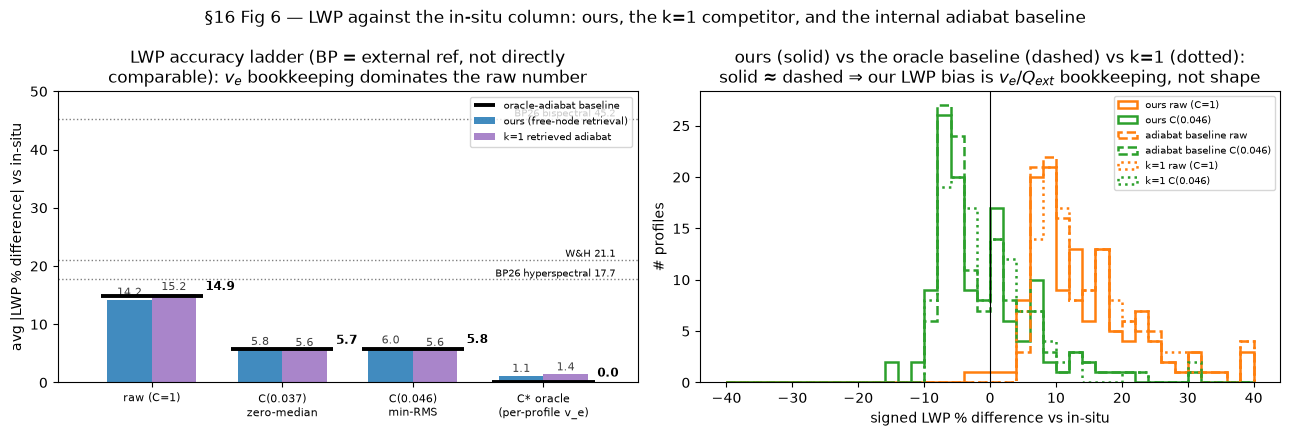

In [10]:
# §16 Fig 6 — LWP: the v_e ladder (post-hoc C-corrections, §5c): ours vs the k=1 competitor
# (purple bars — identity color, user rule 2026-07-18) with the oracle-adiabat BASELINE as bold
# ink markers + direct value labels, all four rungs incl. C*. BP2025/26 shown as an EXTERNAL,
# not-directly-comparable reference (real-Mie + WV retrieval).
if ROWS:
    fig, ax = plt.subplots(1, 2, figsize=(13, 4.4))
    keys = [('lwp_relbias_z', 'raw (C=1)'), ('lwp_relbias_C037', 'C(0.037)\nzero-median'),
            ('lwp_relbias_C046', 'C(0.046)\nmin-RMS'), ('lwp_relbias_Coracle', 'C* oracle\n(per-profile v_e)')]
    akeys = ['lwp_relbias_adia_z', 'lwp_relbias_adia_C037', 'lwp_relbias_adia_C046', 'lwp_relbias_adia_Coracle']
    xs = np.arange(len(keys)); w = 0.34
    bars = ax[0].bar(xs - (w / 2 if K1R else 0), [np.nanmean(np.abs(_g(A, k))) for k, _ in keys], w,
                     color='tab:blue', alpha=.85, label='ours (free-node retrieval)')
    ax[0].bar_label(bars, fmt='%.1f', fontsize=8, padding=1, color='0.25')
    if K1R:
        bars1 = ax[0].bar(xs + w / 2, [np.nanmean(np.abs(_g(K1R, k))) for k, _ in keys], w,
                          color='tab:purple', alpha=.8, label='k=1 retrieved adiabat')
        ax[0].bar_label(bars1, fmt='%.1f', fontsize=8, padding=1, color='0.25')
    # oracle-adiabat baseline: adiabat fit to the truth carries the same width/Q_ext artifact;
    # bold ink marker spanning the group + a direct value label, so the reference is unambiguous.
    base = [np.nanmean(np.abs(_g(A, ak))) for ak in akeys]
    ax[0].hlines(base, xs - 1.15 * w, xs + 1.15 * w, colors='k', lw=2.8, zorder=6,
                 label='oracle-adiabat baseline')
    for x, b in zip(xs, base):
        ax[0].annotate(f'{b:.1f}', (x + 1.15 * w, b), xytext=(2, 2), textcoords='offset points',
                       ha='left', va='bottom', fontsize=8.5, fontweight='bold', color='k', zorder=7)
    for y, t in [(45.2, 'BP26 bispectral 45.2'), (21.1, 'W&H 21.1'), (17.7, 'BP26 hyperspectral 17.7')]:
        ax[0].axhline(y, color='gray', ls=':', lw=1)
        ax[0].text(len(keys) - .45, y + .5, t, fontsize=7, ha='right')
    ax[0].set_xticks(xs); ax[0].set_xticklabels([t for _, t in keys], fontsize=8)
    ax[0].set_xlim(-.72, len(keys) - .28); ax[0].set_ylim(0, 50)
    ax[0].set(ylabel='avg |LWP % difference| vs in-situ',
              title='LWP accuracy ladder (BP = external ref, not directly\ncomparable): $v_e$ bookkeeping dominates the raw number')
    ax[0].legend(fontsize=7.5, loc='upper right')
    bins = np.linspace(-40, 40, 41)
    _hists = [('lwp_relbias_z', A, 'ours raw (C=1)', 'C1', '-'),
              ('lwp_relbias_C046', A, 'ours C(0.046)', 'C2', '-'),
              ('lwp_relbias_adia_z', A, 'adiabat baseline raw', 'C1', '--'),
              ('lwp_relbias_adia_C046', A, 'adiabat baseline C(0.046)', 'C2', '--')]
    if K1R:
        _hists += [('lwp_relbias_z', K1R, 'k=1 raw (C=1)', 'C1', ':'),
                   ('lwp_relbias_C046', K1R, 'k=1 C(0.046)', 'C2', ':')]
    for k, RR, lab, c, ls in _hists:
        ax[1].hist(np.clip(_g(RR, k), -40, 40), bins=bins, histtype='step', lw=1.8, color=c, ls=ls, label=lab)
    ax[1].axvline(0, color='k', lw=.8); ax[1].legend(fontsize=7)
    ax[1].set(xlabel='signed LWP % difference vs in-situ', ylabel='# profiles',
              title='ours (solid) vs the oracle baseline (dashed) vs k=1 (dotted):\n'
                    'solid ≈ dashed ⇒ our LWP bias is $v_e$/$Q_{ext}$ bookkeeping, not shape')
    fig.suptitle('§16 Fig 6 — LWP against the in-situ column: ours, the k=1 competitor, and the '
                 'internal adiabat baseline', fontsize=12)
    fig.tight_layout(); plt.show()

### Finding 8 — health, the low-confidence tail, and UQ honesty

**Health.** FR: one `converged=False` (idx 1, iteration cap on $\chi^2_r$ = 0.003 — a technicality); the two structural-misfit flags are the *accepted* pathology-3 picks idx 49/57 ($\chi^2_r$ 0.18/0.14, true-τ_bot-fed prior provenance); four promoted pathology records (idx 32/49/54/57); no profile touches the $r_e$ = 22 µm table ceiling. k=1: 9 iteration-cap technicalities ($\chi^2_r \le 0.05$), no ceiling contact, **no surviving structural misfit** — three promoted basin-rescue records (idx 8/92/119, true-τ_bot-fed prior provenance; idx 92 keeps a graded tail-level residual — Finding 5).

**The low-confidence tail (13 of 125, worst-decile $\hat{W}_1$ ≥ 1.43).** *Flag rebased 2026-07-16: the earlier worst-decile-$d_{W_1}$ criterion was in absolute τ units — support-scaled, so a thin cloud could never trip it however poor its fit (idx 92, among the worst $\hat{W}_1$, escaped at $\tau_{\rm bot}$≈2.2). The flag now lives on the canonical $\hat{W}_1$.* Members, worst first: idx 119 (3.79), 57 (3.46), 92 (3.29), 54 (2.34), 29, 13, 28, 110, 11, 32 (1.65, post-promotion), 36, 42, 41 (1.46) — the same 13 members as before the idx-32 rescue, which moved idx 32 from the top of this list (4.10) to mid-pack without leaving it. Still deep-heavy (median $\tau_{\rm bot}$ ≈ 19 vs population ≈ 10) but no longer deep-only. $\chi^2_r$ sits at or near the floor throughout: good data-fit, untrustworthy profile — *flagged, not dropped*. The k=1 campaign now **diagnoses the tail**: idx 32 (a ×8 k=1 win even post-rescue) and idx 123 (the worst floor-relative case, +2379 %) are prior-sabotaged climatology outliers (Finding 2), not hard clouds; the promoted idx 119 record (k=1 pathology flag) moves that τ≈42 watch case into the same our-failure column (k=1 reaches $\hat{W}_1$ 0.40 where we sit at 3.79); idx 92 is the genuinely hard, residually-misfit truth (Finding 5). The worst *floor-relative* errors (idx 123 +2379 %, 119 +1720 %, 42 +1387 %) are still not all flagged — idx 123's $\hat{W}_1$ is a mid-pack 1.25 against a near-adiabatic truth whose oracle floor is nearly perfect, so a huge %err there costs little in absolute shape.

**UQ honesty.** Posterior calibration (Fig 5a): the $r_e$-block PIT sits high (median **0.81**) and heavy-right-tailed — **~42 % of truths fall outside the 95 % posterior ellipsoid**: the Rodgers $\hat S$ omits the representation/regularization bias (§13b), which dominates at depth; report $\hat\sigma$ with that caveat. The under-dispersion also explains the demonstrated-and-resolved significance false-alarm (idx 32, Finding 5). The adiabat-inside-posterior test at the **70 % level** (Fig 5b): **14 % of clouds are significantly non-adiabatic**, nearly regime-flat (thin 16 % / mid 12 % / deep 19 %), unlike the 95 % test (9 %, deep-skewed). The three most significant cases (Fig 5b montage) include the genuinely thin idx 92 (τ≈2.2, $d^2/\chi^2_{0.70}$ = 8.1; also low-confidence — read it as "no adiabat fits its posterior", not as trust in its profile detail) alongside idx 14 (τ≈23) and idx 5 (τ≈17). Note the k=1 posterior is *confidently wrong* at depth (fully determined, DOFS ≈ 2.7/3, yet tied with us in error — Finding 3): between an under-dispersed-but-widening posterior and a rigid model's false certainty, ours fails the safer way. (The k=2 give-up grids, idx 49/57, are adiabat-representable by construction and cannot fire the significance test.)

In [11]:
'''
# §16 Fig 3 — prior-draw luck (A vs B): paired d_W1, the (B−A) distribution, and what a
# "luckier" draw buys: best-of-{A,B} as a 2-restart oracle.
if ROWS:
    ia = {r['index']: r for r in A}; ib = {r['index']: r for r in B}
    common = sorted(set(ia) & set(ib))
    dA = np.array([ia[i]['d_w1'] for i in common]); dB = np.array([ib[i]['d_w1'] for i in common])
    fig, ax = plt.subplots(1, 3, figsize=(14, 4.2))
    lim = [min(dA.min(), dB.min()) - .05, max(dA.max(), dB.max()) + .05]
    ax[0].scatter(dA, dB, s=14, alpha=.6); ax[0].plot(lim, lim, 'k:', lw=1)
    ax[0].axhline(0, color='k', lw=.6); ax[0].axvline(0, color='k', lw=.6)
    ax[0].set(xlabel='d_W1, config A [τ]', ylabel='d_W1, config B [τ]',
              title=f'paired by profile (r={np.corrcoef(dA, dB)[0, 1]:.2f})\nbelow diagonal = the draw hurt')
    ax[1].hist(dB - dA, bins=31, color='C4', alpha=.85)
    ax[1].axvline(0, color='k', lw=.8)
    ax[1].set(xlabel='d_W1(B) − d_W1(A) [τ]',
              title=f'draw effect: median {np.median(dB - dA):+.4f} τ\n'
                    f'p10 {np.percentile(dB - dA, 10):+.3f} / p90 {np.percentile(dB - dA, 90):+.3f}')
    best2 = np.maximum(dA, dB)
    ax[2].ecdf(dA, label=f'A (median {np.median(dA):+.3f})')
    ax[2].ecdf(dB, label=f'B (median {np.median(dB):+.3f})')
    ax[2].ecdf(best2, label=f'best-of-2 (median {np.median(best2):+.3f})')
    ax[2].axvline(0, color='k', lw=.6); ax[2].grid(alpha=.3); ax[2].legend(fontsize=8)
    ax[2].set(xlabel='d_W1 [τ]', ylabel='CDF', title='restart value: best-of-{A,B}\n(what "being lucky" buys)')
    fig.tight_layout(); plt.show()
    LC = {(m[0], m[1]) for m in SUMMARY['flags']['low_confidence']['members']}
    both_lc = [i for i in common if (i, 'A') in LC and (i, 'B') in LC]
    print(f'low-confidence in BOTH configs (profile-intrinsic, not draw luck): {both_lc}')
    if REDRAW is not None:                     # the "+1": the fortune-adjusted 124-B re-draw
        r0 = ib.get(124)
        print(f"124-B, the catastrophic-but-VALID draw (in the 250): d_W1 {r0['d_w1']:+.3f}, "
              f"χ²ᵣ {r0['chi2_red']:.3g}, n_gn {r0['n_gn']}  ->  the +1 RE-DRAW (outside the 250): "
              f"d_W1 {REDRAW['d_w1']:+.3f}, χ²ᵣ {REDRAW['chi2_red']:.3g} — the draw, not the "
              f"machinery, was the failure; cf. config A: d_W1 {ia[124]['d_w1']:+.3f}")
'''

'\n# §16 Fig 3 — prior-draw luck (A vs B): paired d_W1, the (B−A) distribution, and what a\n# "luckier" draw buys: best-of-{A,B} as a 2-restart oracle.\nif ROWS:\n    ia = {r[\'index\']: r for r in A}; ib = {r[\'index\']: r for r in B}\n    common = sorted(set(ia) & set(ib))\n    dA = np.array([ia[i][\'d_w1\'] for i in common]); dB = np.array([ib[i][\'d_w1\'] for i in common])\n    fig, ax = plt.subplots(1, 3, figsize=(14, 4.2))\n    lim = [min(dA.min(), dB.min()) - .05, max(dA.max(), dB.max()) + .05]\n    ax[0].scatter(dA, dB, s=14, alpha=.6); ax[0].plot(lim, lim, \'k:\', lw=1)\n    ax[0].axhline(0, color=\'k\', lw=.6); ax[0].axvline(0, color=\'k\', lw=.6)\n    ax[0].set(xlabel=\'d_W1, config A [τ]\', ylabel=\'d_W1, config B [τ]\',\n              title=f\'paired by profile (r={np.corrcoef(dA, dB)[0, 1]:.2f})\nbelow diagonal = the draw hurt\')\n    ax[1].hist(dB - dA, bins=31, color=\'C4\', alpha=.85)\n    ax[1].axvline(0, color=\'k\', lw=.8)\n    ax[1].set(xlabel=\'d_W1(B) − d_W1(A) [

**Bottom line.** On the self-consistent corrected-width OSSE, the multi-angle 10-band system retrieves *what is physically retrievable*: $\tau_{\rm bot}$ to −0.1 % (and to 0.3 % even under a forced-adiabat state — Finding 6), width-corrected LWP at ~6 % (indistinguishable from a perfect-shape adiabat's bookkeeping), and profile shape at $\hat{W}_1$ ≈ 0.4 — ~70× better than the climatology prior. Against the **matched adiabatic retrieval** — the same information, the literature's model class — the free-node state **wins the head-to-head** (shape 59 %, LWP 64 %, both 50 %; −20 % median shape error), decisively so for mid-τ clouds, modestly thin, and fights to a draw deep, where the veiled core caps *every* estimator. No cloud survives as a hard radiance-space rejection of the adiabat class: all three loud $\chi^2_r$ alarms proved to be optimization basins, rescued by the pathology treatment and promoted with its provenance flag (idx 92 keeps a graded, tail-level residual on the cloud our posterior test ranks most non-adiabatic), and the graded k=1 $\chi^2_r$ corroborates that significance test (p = 9×10⁻¹¹). The truth-fed $W_1$-oracle floor remains unreachable for both radiance-driven methods (+60 % us, +81 % k=1) and is approached/beaten exactly where the truth is non-adiabatic. *Caveats: noiseless OSSE, no above-cloud water-vapor retrieval, $Q_{\rm ext}=2$ self-consistency; idx 32/49/54/57 (FR) and idx 8/92/119 (k=1) carry the true-τ_bot-fed-prior provenance flag; curvature Tikhonov λ=1.0 throughout; the k=1 campaign re-ran the τ_bot pre-retrieval (setup provenance in the intro).*